### EDA y ETL final

# EDA

Instalación de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis estadístico
from scipy import stats

# Utilidades
import warnings
warnings.filterwarnings("ignore")

# Configuración visual
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

Traducción de variables y categorías

In [2]:
# Lectura y copia de dataframe
df = pd.read_csv(r"D:\1System\Documentos\Importantes\Henry\Bootcamp DS\PF\ProyFin_Henry_E03\Brazilian E-Commerce Public Dataset by Olist.csv")
df_es = df.copy()

# Traducción de columnas
columnas_es = {
    "Unnamed: 0": "indice_original",
    "order_id": "id_pedido",
    "order_item_id": "id_articulo_pedido",
    "customer_id": "id_cliente",
    "customer_unique_id": "id_cliente_unico",
    "customer_zip_code_prefix": "prefijo_codigo_postal_cliente",
    "customer_city": "ciudad_cliente",
    "customer_state": "estado_cliente",
    "product_id": "id_producto",
    "product_category_name": "categoria_producto",
    "product_name_lenght": "longitud_nombre_producto",
    "product_description_lenght": "longitud_descripcion_producto",
    "product_photos_qty": "cantidad_fotos_producto",
    "product_weight_g": "peso_producto_g",
    "product_length_cm": "largo_producto_cm",
    "product_height_cm": "alto_producto_cm",
    "product_width_cm": "ancho_producto_cm",
    "seller_id": "id_vendedor",
    "seller_city": "ciudad_vendedor",
    "seller_state": "estado_vendedor",
    "seller_zip_code_prefix": "prefijo_codigo_postal_vendedor",
    "payment_type": "tipo_pago",
    "payment_sequential": "secuencia_pago",
    "payment_installments": "cuotas_pago",
    "price": "precio",
    "freight_value": "valor_flete",
    "payment_value": "valor_pago",
    "shipping_limit_date": "fecha_limite_envio",
    "order_purchase_timestamp": "fecha_compra",
    "order_approved_at": "fecha_aprobacion_pedido",
    "order_delivered_carrier_date": "fecha_entrega_transportista",
    "order_delivered_customer_date": "fecha_entrega_cliente",
    "order_estimated_delivery_date": "fecha_estimada_entrega",
    "day_of_purchase": "dia_compra",
    "month_of_purchase": "mes_compra",
    "year_of_purchase": "anio_compra",
    "month/year_of_purchase": "mes_anio_compra",
    "order_status": "estado_pedido",
    "order_unique_id": "id_pedido_unico"
}

# Reemplazo de los nombres de columnas
df_es.rename(columns=columnas_es, inplace=True)


# Traducción de categorías
categorias_es = {
    "cool_stuff": "articulos_interesantes",
    "brinquedos": "juguetes",
    "tablets_impressao_imagem": "tabletas_impresion_imagen",
    "pet_shop": "productos_para_mascotas",
    "moveis_decoracao": "muebles_decoracion",
    "cama_mesa_banho": "cama_mesa_bano",
    "perfumaria": "perfumeria",
    "informatica_acessorios": "informatica_accesorios",
    "utilidades_domesticas": "articulos_domesticos",
    "papelaria": "papeleria",
    "ferramentas_jardim": "herramientas_jardin",
    "esporte_lazer": "deportes_ocio",
    "telefonia": "telefonia",
    "audio": "audio",
    "beleza_saude": "belleza_salud",
    "construcao_ferramentas_jardim": "construccion_herramientas_jardin",
    "relogios_presentes": "relojes_regalos",
    "bebes": "bebes",
    "livros_tecnicos": "libros_tecnicos",
    "dvds_blu_ray": "dvds_blu_ray",
    "consoles_games": "consolas_videojuegos",
    "alimentos": "alimentos",
    "fashion_bolsas_e_acessorios": "moda_bolsos_accesorios",
    "casa_conforto": "hogar_confort",
    "moveis_sala": "muebles_sala",
    "casa_conforto_2": "hogar_confort_2",
    "instrumentos_musicais": "instrumentos_musicales",
    "automotivo": "automotriz",
    "moveis_escritorio": "muebles_oficina",
    "casa_construcao": "hogar_construccion",
    "construcao_ferramentas_iluminacao": "construccion_herramientas_iluminacion",
    "eletronicos": "electronicos",
    "sinalizacao_e_seguranca": "senalizacion_seguridad",
    "cine_foto": "cine_fotografia",
    "construcao_ferramentas_construcao": "construccion_herramientas_construccion",
    "telefonia_fixa": "telefonia_fija",
    "fraldas_higiene": "panales_higiene",
    "pc_gamer": "computadoras_gamer",
    "fashion_roupa_masculina": "moda_ropa_masculina",
    "eletroportateis": "electrodomesticos_portatiles",
    "industria_comercio_e_negocios": "industria_comercio_negocios",
    "construcao_ferramentas_seguranca": "construccion_herramientas_seguridad",
    "fashion_esporte": "moda_deportiva",
    "malas_acessorios": "maletas_accesorios",
    "market_place": "mercado_en_linea",
    "construcao_ferramentas_ferramentas": "construccion_herramientas",
    "eletrodomesticos": "electrodomesticos",
    "agro_industria_e_comercio": "agroindustria_comercio",
    "climatizacao": "climatizacion",
    "artes": "arte",
    "la_cuisine": "cocina",
    "portateis_casa_forno_e_cafe": "portatiles_hogar_horno_cafe",
    "moveis_cozinha_area_de_servico_jantar_e_jardim":
        "muebles_cocina_servicio_comedor_jardin",
    "livros_interesse_geral": "libros_interes_general",
    "eletrodomesticos_2": "electrodomesticos_2",
    "alimentos_bebidas": "alimentos_bebidas",
    "musica": "musica",
    "moveis_quarto": "muebles_dormitorio",
    "fashion_calcados": "moda_calzado",
    "bebidas": "bebidas",
    "artigos_de_natal": "articulos_navidenos",
    "artigos_de_festas": "articulos_fiestas",
    "moveis_colchao_e_estofado": "muebles_colchones_tapiceria",
    "cds_dvds_musicais": "cds_dvds_musicales",
    "seguros_e_servicos": "seguros_servicios",
    "fashion_roupa_infanto_juvenil": "moda_ropa_infantil_juvenil",
    "fashion_roupa_feminina": "moda_ropa_femenina",
    "pcs": "computadoras",
    "fashion_underwear_e_moda_praia": "moda_ropa_interior_playa",
    "livros_importados": "libros_importados",
    "artes_e_artesanato": "arte_artesanias",
    "flores": "flores",
    "portateis_cozinha_e_preparadores_de_alimentos":
        "portatiles_cocina_preparacion_alimentos"
}

# Creación y llenado de nueva columna
df_es["categoria_producto"] = (
    df_es["categoria_producto"].replace(categorias_es)
    )

# Traducción de los tipos de pago
tipos_pago_es = {
    "credit_card": "tarjeta_credito",
    "debit_card": "tarjeta_debito",
    "boleto": "boleto_bancario",
    "voucher": "cupon"
}

# Traducción del estado del pedido
estados_pedido_es = {
    "delivered": "entregado",
    "canceled": "cancelado"
}

# Traducción de los días de la semana
dias_es = {
    "Monday": "lunes",
    "Tuesday": "martes",
    "Wednesday": "miercoles",
    "Thursday": "jueves",
    "Friday": "viernes",
    "Saturday": "sabado",
    "Sunday": "domingo"
}

# Traducción de los meses
meses_es = {
    "January": "enero",
    "February": "febrero",
    "March": "marzo",
    "April": "abril",
    "May": "mayo",
    "June": "junio",
    "July": "julio",
    "August": "agosto",
    "September": "septiembre",
    "October": "octubre",
    "November": "noviembre",
    "December": "diciembre"
}

# Creación y llenado de columnas
df_es["tipo_pago"] = df_es["tipo_pago"].replace(tipos_pago_es)
df_es["estado_pedido"] = df_es["estado_pedido"].replace(estados_pedido_es)
df_es["dia_compra"] = df_es["dia_compra"].replace(dias_es)
df_es["mes_compra"] = df_es["mes_compra"].replace(meses_es)


# Comprobación visual
print("Columnas del DataFrame original:")
display(df.head(2))

print("Columnas del DataFrame traducido:")
display(df_es.head(2))

Columnas del DataFrame original:


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,seller_zip_code_prefix,payment_type,payment_sequential,payment_installments,price,freight_value,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,credit_card,1,2,58.90,13.29,72.19,2017-09-19 09:45:35,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,boleto,1,1,55.90,17.96,73.86,2017-07-05 02:44:11,2017-06-28 11:52:20,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1


Columnas del DataFrame traducido:


,indice_original,id_pedido,id_articulo_pedido,id_cliente,id_cliente_unico,prefijo_codigo_postal_cliente,ciudad_cliente,estado_cliente,id_producto,categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_producto_g,largo_producto_cm,alto_producto_cm,ancho_producto_cm,id_vendedor,ciudad_vendedor,estado_vendedor,prefijo_codigo_postal_vendedor,tipo_pago,secuencia_pago,cuotas_pago,precio,valor_flete,valor_pago,fecha_limite_envio,fecha_compra,fecha_aprobacion_pedido,fecha_entrega_transportista,fecha_entrega_cliente,fecha_estimada_entrega,dia_compra,mes_compra,anio_compra,mes_anio_compra,estado_pedido,id_pedido_unico
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,tarjeta_credito,1,2,58.90,13.29,72.19,2017-09-19 09:45:35,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,miercoles,septiembre,2017,September-2017,entregado,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,articulos_interesantes,58.00,598.00,4.00,650.00,28.00,9.00,14.00,48436dade18ac8b2bce089ec2a041202,volta redonda,SP,27277,boleto_bancario,1,1,55.90,17.96,73.86,2017-07-05 02:44:11,2017-06-28 11:52:20,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,miercoles,junio,2017,June-2017,entregado,130898c0987d1801452a8ed92a670612-1


### Información estructural del dataset

In [3]:
# Dimensiones del DataFrame
print(f"El dataset contiene {df_es.shape[0]:,} filas y {df_es.shape[1]} columnas.")
df_es.info()

El dataset contiene 113,390 filas y 39 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   indice_original                 113390 non-null  int64  
 1   id_pedido                       113390 non-null  str    
 2   id_articulo_pedido              113390 non-null  int64  
 3   id_cliente                      113390 non-null  str    
 4   id_cliente_unico                113390 non-null  str    
 5   prefijo_codigo_postal_cliente   113390 non-null  int64  
 6   ciudad_cliente                  113390 non-null  str    
 7   estado_cliente                  113390 non-null  str    
 8   id_producto                     113390 non-null  str    
 9   categoria_producto              113390 non-null  str    
 10  longitud_nombre_producto        113390 non-null  float64
 11  longitud_descripcion_producto   113390 n

### Análisis de calidad de los datos

Valores NULOS

In [4]:
# Resumen de calidad por columna
calidad = pd.DataFrame({
    "tipo_dato": df_es.dtypes,
    "no_nulos": df_es.notna().sum(),
    "nulos": df_es.isna().sum(),
    "porcentaje_nulos": df_es.isna().mean().mul(100),
    "valores_unicos": df_es.nunique(),
    "porcentaje_unicos": df_es.nunique().div(len(df_es)).mul(100)
}).sort_values("porcentaje_nulos", ascending=False)

# Redondeo de porcentajes
calidad[["porcentaje_nulos", "porcentaje_unicos"]] = (
    calidad[["porcentaje_nulos", "porcentaje_unicos"]].round(2)
)
calidad

,tipo_dato,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos
indice_original,int64,113390,0,0.00,113390,100.00
id_pedido,str,113390,0,0.00,95128,83.89
id_articulo_pedido,int64,113390,0,0.00,21,0.02
id_cliente,str,113390,0,0.00,95128,83.89
id_cliente_unico,str,113390,0,0.00,92081,81.21
prefijo_codigo_postal_cliente,int64,113390,0,0.00,14844,13.09
ciudad_cliente,str,113390,0,0.00,4073,3.59
estado_cliente,str,113390,0,0.00,27,0.02
id_producto,str,113390,0,0.00,31625,27.89
categoria_producto,str,113390,0,0.00,73,0.06


In [5]:
print(f"Filas duplicadas completas: {df_es.duplicated().sum():,}")
print(f"Columnas con valores nulos: {(df_es.isna().sum() > 0).sum()}")
print(f"Columnas completamente vacías: {df_es.isna().all().sum()}")
print(f"Columnas constantes: {(df_es.nunique(dropna=False) <= 1).sum()}")

Filas duplicadas completas: 0
Columnas con valores nulos: 0
Columnas completamente vacías: 0
Columnas constantes: 0


Valores DUPLICADOS

In [6]:
duplicados_completos = df_es.duplicated().sum()

print(f"Filas duplicadas completas: {duplicados_completos:,}")
print(f"Porcentaje: {duplicados_completos/len(df_es)*100}%")

duplicados_articulos = df_es.duplicated(
    subset=["id_pedido", "id_articulo_pedido"]
).sum()

print("Registros duplicados por pedido y artículo:", f"{duplicados_articulos:,}\n")

pedidos_repetidos = (
    df_es["id_pedido"]
    .value_counts()
    .loc[lambda x: x > 1]
)

print(f"Pedidos presentes en más de una fila: {len(pedidos_repetidos):,}")
print(f"Máximo de filas asociadas a un pedido: {pedidos_repetidos.max()}")

pedidos_repetidos.head(10)

Filas duplicadas completas: 0
Porcentaje: 0.0%
Registros duplicados por pedido y artículo: 4,750

Pedidos presentes en más de una fila: 12,056
Máximo de filas asociadas a un pedido: 63


id_pedido
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
ccf804e764ed5650cd8759557269dc13    26
465c2e1bee4561cb39e0db8c5993aafc    24
a3725dfe487d359b5be08cac48b64ec5    24
68986e4324f6a21481df4e6e89abcf01    24
c6492b842ac190db807c15aff21a7dd6    24
285c2e15bebd4ac83635ccc563dc71f4    22
8272b63d03f5f79c56e9e4120aec44ef    21
1c11d0f4353b31ac3417fbfa5f0f2a8a    21
Name: count, dtype: int64

De acuerdo con la información de elementos duplicados, corroboramos su naturaleza utilizando el `id_pedido` con mayor número de repeticiones

In [7]:
pedido_ejemplo = pedidos_repetidos.index[0]

df_es.loc[
    df_es["id_pedido"] == pedido_ejemplo,
    [
        "id_pedido",
        "id_articulo_pedido",
        "id_producto",
        "tipo_pago",
        "secuencia_pago",
        "cuotas_pago",
        "precio",
        "valor_flete",
        "valor_pago"
    ]
].sort_values(
    ["id_articulo_pedido", "secuencia_pago"]
)

,id_pedido,id_articulo_pedido,id_producto,tipo_pago,secuencia_pago,cuotas_pago,precio,valor_flete,valor_pago
92955,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,1,1,12.99,23.21,2.61
92961,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,2,1,12.99,23.21,2.61
92966,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,3,1,12.99,23.21,2.61
92959,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,4,1,12.99,23.21,2.61
92967,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,5,1,12.99,23.21,2.61
92974,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,6,1,12.99,23.21,2.61
92969,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,7,1,12.99,23.21,2.60
92964,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,8,1,12.99,23.21,0.41
92973,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,9,1,12.99,23.21,2.61
92968,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,cupon,10,1,12.99,23.21,16.70


Observamos que sólo surgen cambios en `id_articulo_pedido`, `precio`, `valor_flete`, `valor_pago` y `secuencia_pago`, por lo tanto, esa combinación no funciona como identificador únco de fila.

Comprobaremos si `id_pedido_unico` sí identifica cada fila de manera exclusiva:

In [8]:
print(
    "Duplicados en id_pedido_unico:",
    df_es["id_pedido_unico"].duplicated().sum()
)

print(
    "Valores únicos:",
    df_es["id_pedido_unico"].nunique()
)

print(
    "Total de filas:",
    len(df_es)
)

Duplicados en id_pedido_unico: 4750
Valores únicos: 108640
Total de filas: 113390


In [9]:
# Revisar qué variables cambian dentro de cada pedido-artículo repetido
variacion = (
    df_es.groupby(["id_pedido", "id_articulo_pedido"])
    .agg(
        registros=("id_pedido_unico", "size"),
        precios_distintos=("precio", "nunique"),
        fletes_distintos=("valor_flete", "nunique"),
        pagos_distintos=("valor_pago", "nunique"),
        secuencias_distintas=("secuencia_pago", "nunique"),
        productos_distintos=("id_producto", "nunique"),
        vendedores_distintos=("id_vendedor", "nunique")
    )
    .query("registros > 1")
)

variacion.describe()

,registros,precios_distintos,fletes_distintos,pagos_distintos,secuencias_distintas,productos_distintos,vendedores_distintos
count,"3,169.00","3,169.00","3,169.00","3,169.00","3,169.00","3,169.00","3,169.00"
mean,2.50,1.00,1.00,2.30,2.50,1.00,1.00
std,1.62,0.00,0.00,1.20,1.62,0.00,0.00
min,2.00,1.00,1.00,1.00,2.00,1.00,1.00
25%,2.00,1.00,1.00,2.00,2.00,1.00,1.00
50%,2.00,1.00,1.00,2.00,2.00,1.00,1.00
75%,2.00,1.00,1.00,2.00,2.00,1.00,1.00
max,26.00,1.00,1.00,22.00,26.00,1.00,1.00


No se identificaron filas completamente duplicadas. Sin embargo, 4,750 registros comparten el mismo identificador de pedido-artículo debido a la existencia de múltiples pagos asociados a un mismo pedido.

En estos casos, las características del artículo permanecen constantes, mientras que cambian principalmente la secuencia, el tipo y el valor del pago. Por ello, los registros no deben eliminarse, pero será necesario controlar la granularidad antes de calcular ventas, precios, fletes o cantidades.

- Para analizar productos, tendremos que deduplicar temporalmente por id_pedido_unico
- Para analizar pagos, debemos conservar todas las filas, pero evitando contar el pago una vez por cada artículo

#### Valores inconsistentes o imposibles

In [10]:
# Revisar valores numéricos sospechosos
revision_numerica = pd.DataFrame({
    "minimo": df_es.select_dtypes(include="number").min(),
    "maximo": df_es.select_dtypes(include="number").max(),
    "ceros": (df_es.select_dtypes(include="number") == 0).sum(),
    "negativos": (df_es.select_dtypes(include="number") < 0).sum()
})
revision_numerica

,minimo,maximo,ceros,negativos
indice_original,0.00,"113,389.00",1,0
id_articulo_pedido,1.00,21.00,0,0
prefijo_codigo_postal_cliente,"1,003.00","99,980.00",0,0
longitud_nombre_producto,5.00,76.00,0,0
longitud_descripcion_producto,4.00,"3,992.00",0,0
cantidad_fotos_producto,1.00,20.00,0,0
peso_producto_g,0.00,"40,425.00",8,0
largo_producto_cm,7.00,105.00,0,0
alto_producto_cm,2.00,105.00,0,0
ancho_producto_cm,6.00,118.00,0,0


#### Para un mayor enfoque de las columnas críticas en el análisis de la variable objetivo

In [11]:
# Numéricas
columnas_clave = [
    "precio",
    "valor_flete",
    "valor_pago",
    "peso_producto_g",
    "largo_producto_cm",
    "alto_producto_cm",
    "ancho_producto_cm",
    "cuotas_pago",
    "cantidad_fotos_producto"
]
revision_numerica.loc[columnas_clave]

,minimo,maximo,ceros,negativos
precio,0.85,"6,735.00",0,0
valor_flete,0.00,409.68,386,0
valor_pago,0.00,"13,664.08",4,0
peso_producto_g,0.00,"40,425.00",8,0
largo_producto_cm,7.00,105.00,0,0
alto_producto_cm,2.00,105.00,0,0
ancho_producto_cm,6.00,118.00,0,0
cuotas_pago,0.00,24.00,3,0
cantidad_fotos_producto,1.00,20.00,0,0


In [12]:
# Cantidad de valores distintos en variables categóricas
for columna in [
    "categoria_producto",
    "tipo_pago",
    "estado_pedido",
    "estado_cliente",
    "estado_vendedor"
]:
    print(f"{df_es[columna].value_counts(dropna=False).head(10000)}\n")

categoria_producto
cama_mesa_bano                             11649
belleza_salud                               9761
deportes_ocio                               8731
muebles_decoracion                          8553
informatica_accesorios                      7897
articulos_domesticos                        7172
relojes_regalos                             6063
telefonia                                   4601
herramientas_jardin                         4463
automotriz                                  4283
juguetes                                    4185
articulos_interesantes                      3904
perfumeria                                  3480
bebes                                       3111
electronicos                                2807
papeleria                                   2564
moda_bolsos_accesorios                      2106
productos_para_mascotas                     2005
muebles_oficina                             1753
maletas_accesorios                          1148
c

**CATEGORÍAS**

observamos 73 categorías con cierto desbalance; tenemos categorías muy frecuentes como:
 - `cama_mesa_bano`: 11,649
 - `belleza_salud`: 9,761
 - `deportes_ocio`: 8,731
 - `muebles_decoracion`: 8,553
 - `informatica_accesorios`: 7,897

el extremo contrario muestra:

- `seguros_servicios`: 2
- `moda_ropa_infantil_juvenil`: 7
- `computadoras_gamer`: 9
- `cds_dvds_musicales`: 14

**TIPO DE PAGO**

La tarjeta de crédito domina claramente, la distribución es desbalanceada, los cuatro valores se ven válidos.

- `tarjeta_credito`: 83,706
- `boleto_bancario`: 22,047
- `cupon`: 6,012
- `tarjeta_debito`: 1,625

**ESTADO DE PEDIDO**

Aquí observamos un desbalance extremo, los pedidos cancelados son una fracción diminuta del dataset, por lo que esta variable tendrá poca utilidad para comparar cancelaciones frente a entregas.

- `entregado`: 113,383
- `cancelado`: 7

**ESTADOS DE CLIENTES/VENDEDORES**

Las abreviaturas corresponden a estados brasileños y se ven consistentes. En ambos casos destaca `SP`, aunque con mayor concentración entre los vendedores:

- Clientes de SP: 47,830
- Vendedores de SP: 80,870

Esto sugiere una fuerte concentración comercial en São Paulo.

#### **Precaución importante**

Estos conteos corresponden a filas del DataFrame, no necesariamente a pedidos únicos.

Debido a la multiplicación provocada por artículos y pagos, no debemos afirmar todavía que existen exactamente:

- 83,706 pagos con tarjeta,
- 47,830 clientes de São Paulo,
- 113,383 pedidos entregados.

Son frecuencias de registros. Más adelante calcularemos estas distribuciones usando la unidad correcta de análisis.

### Revisión de coherencia en fechas

In [13]:
columnas_fecha = [
    "fecha_limite_envio",
    "fecha_compra",
    "fecha_aprobacion_pedido",
    "fecha_entrega_transportista",
    "fecha_entrega_cliente",
    "fecha_estimada_entrega"
]

# Transformamos en NaT cualquier valor que no pueda interpretarse como fecha
df_es[columnas_fecha] = df_es[columnas_fecha].apply(
    pd.to_datetime,
    errors="coerce"
)

# Revisión del rango temporal
calidad_fechas = pd.DataFrame({
    "fecha_minima": df_es[columnas_fecha].min(),
    "fecha_maxima": df_es[columnas_fecha].max(),
    "fechas_invalidas": df_es[columnas_fecha].isna().sum()
})

calidad_fechas

,fecha_minima,fecha_maxima,fechas_invalidas
fecha_limite_envio,2016-10-08 10:34:01,2020-04-09 22:35:08,0
fecha_compra,2016-10-03 09:44:50,2018-08-29 15:00:37,0
fecha_aprobacion_pedido,2016-10-04 09:43:32,2018-08-29 15:10:26,0
fecha_entrega_transportista,2016-10-08 10:34:01,2018-09-11 19:48:28,0
fecha_entrega_cliente,2016-10-11 13:46:32,2018-10-17 13:22:46,0
fecha_estimada_entrega,2016-10-27 00:00:00,2018-10-25 00:00:00,0


In [14]:
# Incoherencias temporales
incoherencias_fechas = pd.Series({
    "aprobacion_antes_compra": (
        df_es["fecha_aprobacion_pedido"] < df_es["fecha_compra"]
    ).sum(),

    "entrega_transportista_antes_compra": (
        df_es["fecha_entrega_transportista"] < df_es["fecha_compra"]
    ).sum(),

    "entrega_cliente_antes_transportista": (
        df_es["fecha_entrega_cliente"] <
        df_es["fecha_entrega_transportista"]
    ).sum(),

    "entrega_cliente_antes_compra": (
        df_es["fecha_entrega_cliente"] < df_es["fecha_compra"]
    ).sum()
})

incoherencias_fechas

aprobacion_antes_compra                  0
entrega_transportista_antes_compra     187
entrega_cliente_antes_transportista     58
entrega_cliente_antes_compra             0
dtype: int64

In [15]:
# Cuántos pedidos únicos se ven afectados por las inconsistencias?
problemas_fechas = pd.Series({
    "pedidos_transportista_antes_compra": df_es.loc[
        df_es["fecha_entrega_transportista"] < df_es["fecha_compra"],
        "id_pedido"
    ].nunique(),

    "pedidos_cliente_antes_transportista": df_es.loc[
        df_es["fecha_entrega_cliente"] <
        df_es["fecha_entrega_transportista"],
        "id_pedido"
    ].nunique()
})

problemas_fechas

pedidos_transportista_antes_compra     164
pedidos_cliente_antes_transportista     23
dtype: int64

### Análisis de interacciones Cliente - Producto

In [16]:
interacciones = (
    df_es.sort_values("secuencia_pago").drop_duplicates(
        subset=["id_pedido", "id_articulo_pedido"]
    ).copy()
)

print(f"Filas originales: {len(df_es):,}")
print(f"Interacciones únicas: {len(interacciones):,}")

Filas originales: 113,390
Interacciones únicas: 108,640


Identificamos la cantidad de pedidos, clientes y productos únicos

In [17]:
print("Duplicados por pedido-artículo:", interacciones.duplicated(subset=["id_pedido", "id_articulo_pedido"]).sum())
print(f"Pedidos únicos: {interacciones["id_pedido"].nunique():,}")
print(f"Clientes únicos: {interacciones["id_cliente_unico"].nunique():,}")
print(f"Productos únicos: {interacciones["id_producto"].nunique():,}")

Duplicados por pedido-artículo: 0
Pedidos únicos: 95,128
Clientes únicos: 92,081
Productos únicos: 31,625


Como no contamos con datos que describan interacción con la e-commerce como clics, tiempo de navegación, etc., analizaremos cuántos pedidos e interacciones tiene cada cliente. El resultado nos permitirá definir si es posible hacer recomendaciones personalizadas o si tendremos que apoyarnos más en la popularidad y similitud de los productos.

In [18]:
# Análisis de compras por cliente
historial_clientes = (
    interacciones.groupby("id_cliente_unico").agg(
        pedidos=("id_pedido", "nunique"),
        productos_comprados=("id_producto", "count"),
        productos_unicos=("id_producto", "nunique")
    ))

historial_clientes.describe()

,pedidos,productos_comprados,productos_unicos
count,"92,081.00","92,081.00","92,081.00"
mean,1.03,1.18,1.07
std,0.21,0.62,0.31
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,1.00,1.00
75%,1.00,1.00,1.00
max,14.00,24.00,13.00


In [19]:
# Cálculo de clientes que tienen uno o más pedidos
distribucion_pedidos_cliente = (
    historial_clientes["pedidos"].value_counts().sort_index()
)

distribucion_pedidos_cliente.head(10)

pedidos
1     89340
2      2520
3       175
4        29
5         9
6         3
7         3
9         1
14        1
Name: count, dtype: int64

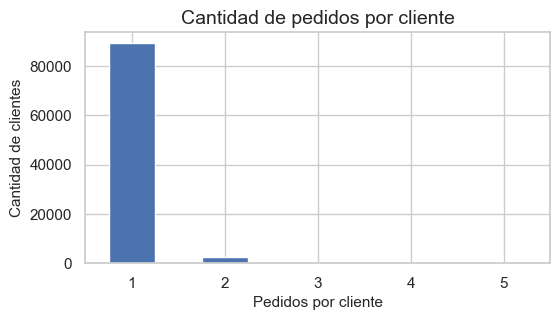

Clientes con un solo pedido: 97.02%
Clientes recurrentes: 2.98%


In [20]:
# Visualización
historial_clientes["pedidos"].clip(upper=5).value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 3),
    title="Cantidad de pedidos por cliente"
)

plt.xlabel("Pedidos por cliente")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

plt.show()

# Distribución porcentual de recurrencia
clientes_un_pedido = (historial_clientes["pedidos"] == 1).mean() * 100
clientes_recurrentes = (historial_clientes["pedidos"] > 1).mean() * 100

print(f"Clientes con un solo pedido: {clientes_un_pedido:.2f}%")
print(f"Clientes recurrentes: {clientes_recurrentes:.2f}%")

El resultado nos brinda información valiosa, podemos confirmar que existe una fuerte tendencia de ***cold start de usuarios***: para casi todos los clientes no existe historial suficiente como para aprender preferencias personales con filtrado colaborativo tradicional, con lo cual:

- Sería un riesgo que el sistema dependa únicamente del historial individual para generar recomendaciones.
- Existe una clara oportunidad para promover la recompra si podemos aprovechar y mejorar cada visita y cada compra.

Una estrategia razonable podría incluír:

- Popularidad general.
- Popularidad por categoría.
- Similitud entre productos.
- Productos comprados juntos.
- Personalización para el pequeño grupo de clientes recurrentes.

Nos conviene entonces analizar el tamaño del carrito por pedido, pues está directamente relacionado con la venta cruzada y el ticket promedio.

In [21]:
# Cantidad de artículos y productos distintos por pedido
canasta_pedidos = (
    interacciones.groupby("id_pedido").agg(
        articulos=("id_articulo_pedido", "count"),
        productos_unicos=("id_producto", "nunique")
    ))

canasta_pedidos.describe()

,articulos,productos_unicos
count,"95,128.00","95,128.00"
mean,1.14,1.04
std,0.54,0.23
min,1.00,1.00
25%,1.00,1.00
50%,1.00,1.00
75%,1.00,1.00
max,21.00,8.00


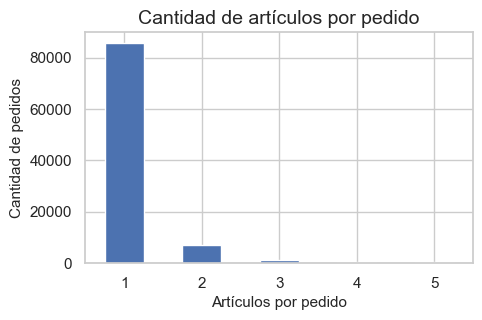

Pedidos con un solo artículo: 90.02%
Pedidos con varios artículos: 9.98%


In [22]:
# Visualización
canasta_pedidos["articulos"].clip(upper=5).value_counts().sort_index().plot(
    kind="bar",
    figsize=(5, 3),
    title="Cantidad de artículos por pedido"
)

plt.xlabel("Artículos por pedido")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=0)
plt.show()

# Proporción porcentual
pedidos_un_producto = (canasta_pedidos["articulos"] == 1).mean() * 100
pedidos_multiproducto = (canasta_pedidos["articulos"] > 1).mean() * 100

print(f"Pedidos con un solo artículo: {pedidos_un_producto:.2f}%")
print(f"Pedidos con varios artículos: {pedidos_multiproducto:.2f}%")

Los resultados refuerzan bastante el problema del negocio. La mayoría de las compras no incorporan productos adicionales, lo que sugiere una oportunidad clara para aplicar recomendaciones orientadas a:

- Productos complementarios
- Venta cruzada
- Paquetes o combinaciones frecuentes
- Sugerencias dentro del carrito
- recomendaciones posteriores a seleccionar un producto

El hecho de que sólo cerca del 10% de los pedidos tenga múltipes artículos limita la cantidad de asociaciones disponibles, pero sigue dejando varios miles de canastas útiles para descubrir productos comprados juntos.

En consecuencia revisaremos el comportamiento del ticket promedio por pedido. Para calcularlo correctamente, debemos trabajar a nivel de pedido y evitar sumar varias veces los pagos o los artículos repetidos.

Primero calculamos el valor de los productos y del flete por pedido:

In [23]:
# Resumen económico por pedido
ticket_pedidos = (
    interacciones.groupby("id_pedido").agg(
        valor_productos=("precio", "sum"),
        valor_flete=("valor_flete", "sum"),
        cantidad_articulos=("id_articulo_pedido", "count"),
        productos_unicos=("id_producto", "nunique")
    ))

# Ticket total del pedido
ticket_pedidos["ticket_total"] = (
    ticket_pedidos["valor_productos"] + ticket_pedidos["valor_flete"]
)

ticket_pedidos.describe()

,valor_productos,valor_flete,cantidad_articulos,productos_unicos,ticket_total
count,"95,128.00","95,128.00","95,128.00","95,128.00","95,128.00"
mean,137.14,22.82,1.14,1.04,159.97
std,208.91,21.61,0.54,0.23,218.68
min,0.85,0.00,1.00,1.00,9.59
25%,45.90,13.85,1.00,1.00,61.97
50%,86.00,17.22,1.00,1.00,105.15
75%,149.90,24.08,1.00,1.00,176.81
max,"13,440.00","1,794.96",21.00,8.00,"13,664.08"


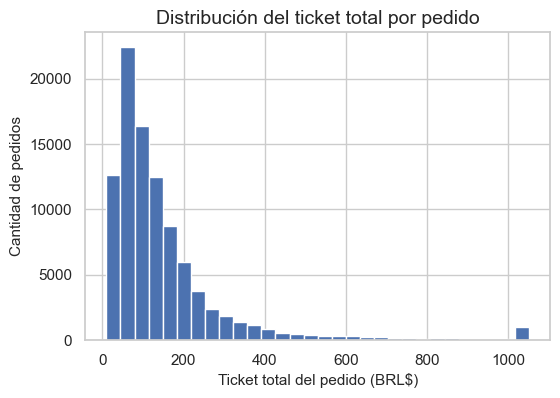

Ticket promedio sin flete: BRL $ 137.14
Ticket promedio con flete: BRL $ 159.97
Mediana del ticket total: BRL $ 105.15


In [24]:
# Visualización
ticket_pedidos["ticket_total"].clip(
    upper=ticket_pedidos["ticket_total"].quantile(0.99)
).plot(
    kind="hist",
    bins=30,
    figsize=(6, 4),
    title="Distribución del ticket total por pedido"
)

plt.xlabel("Ticket total del pedido (BRL$)")
plt.ylabel("Cantidad de pedidos")
plt.show()

# Indicadores principales
print(
    f"Ticket promedio sin flete: "
    f"BRL $ {ticket_pedidos['valor_productos'].mean():,.2f}"
)

print(
    f"Ticket promedio con flete: "
    f"BRL $ {ticket_pedidos['ticket_total'].mean():,.2f}"
)

print(
    f"Mediana del ticket total: "
    f"BRL $ {ticket_pedidos['ticket_total'].median():,.2f}"
)

La diferencia que hay entre media y mediana indica una distribución sesgada a la derecha: la mayoría de los pedidos muy altos elevan el promedio, sin embargo, la gráfica confirma que la mayor concentración está en tickets bajos y medios, por debajo de los $200 BRL, mientras que existe una cola larga de pedidios costosos, por los que una estrategia de recomendaciones complementarias podría incrementar gradualmente el valor de los pedidos más frecuentes sin depender de los casos extremos.

Pasaremos entonces a analizar el ticket según la cantidad de artículos, por lo que comprobaremos si los pedidos con varios artículos realmente derivan en un valor de ticket mayor o si los tickets de mayor valor se deben a productos más costosos. 

In [25]:
# Agrupar pedidos según la cantidad de artículos
ticket_por_articulos = (
    ticket_pedidos.assign(grupo_articulos=ticket_pedidos["cantidad_articulos"].clip(upper=5)).groupby("grupo_articulos").agg(
        pedidos=("ticket_total", "count"),
        ticket_promedio=("ticket_total", "mean"),
        ticket_mediano=("ticket_total", "median")
    ).round(2)
)

ticket_por_articulos

,pedidos,ticket_promedio,ticket_mediano
grupo_articulos,,,
1,85637,150.10,98.69
2,7286,211.69,155.14
3,1280,293.32,210.98
4,490,391.52,270.10
5,435,581.87,369.66


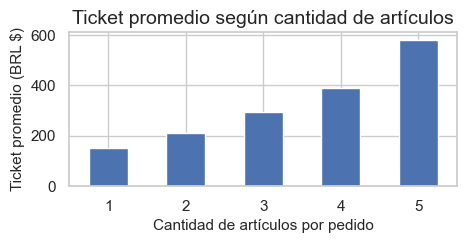

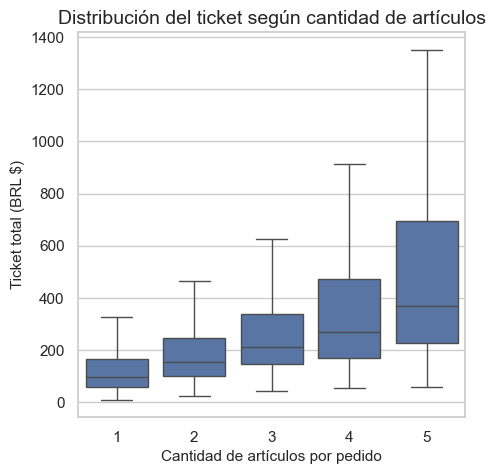

In [26]:
# Visualización
ticket_por_articulos["ticket_promedio"].plot(
    kind="bar",
    figsize=(5, 2),
    title="Ticket promedio según cantidad de artículos"
)

plt.xlabel("Cantidad de artículos por pedido")
plt.ylabel("Ticket promedio (BRL $)")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(5, 5))

sns.boxplot(
    data=ticket_pedidos.assign(
        grupo_articulos=ticket_pedidos["cantidad_articulos"].clip(upper=5)
    ),
    x="grupo_articulos",
    y="ticket_total",
    showfliers=False
)

plt.title("Distribución del ticket según cantidad de artículos")
plt.xlabel("Cantidad de artículos por pedido")
plt.ylabel("Ticket total (BRL $)")
plt.show()

Afortunadamente podemos observar una relación positiva entre la cantidad de artículos y el valor del ticket. Los pedidos con un sólo producto muestran un valor progresivamente más bajo que aquellos con cinco o más artículos. Este comportamiento respalda una estrategia de recomendaciones complementarias, pues incrementar la cantidad de productos parece contribuir al aumento del valor del ticket promedio.

No obstante, esta relación debe interpretarse como asociativa y no casual, debido a que también puede estar influida por el tipo y precio de los productos incluídos.

Vamos entonces a identificar pares de productos que aprecen dentro del mismo pedido. Este análisis es central para construir recomendaciones complementarias. Primero nos quedamos únicamente con pedidos que contienen más de un producto distinto.

In [27]:
# Construcción y conteo de combinaciones
from itertools import combinations
from collections import Counter

# Productos únicos por pedido
productos_por_pedido = (
    interacciones.groupby("id_pedido")["id_producto"].apply(lambda x: sorted(set(x)))
)

# Conservar pedidos con al menos dos productos distintos
pedidos_multiproducto = productos_por_pedido[productos_por_pedido.apply(len) > 1]

print(f"Pedidos útiles para asociaciones: {len(pedidos_multiproducto):,}")

# Generar y contar pares de productos comprados juntos
conteo_pares = Counter(
    par
    for productos in pedidos_multiproducto
    for par in combinations(productos, 2)
)

pares_frecuentes = pd.DataFrame(
    conteo_pares.most_common(4000),
    columns=["par_productos", "frecuencia"]
)

pares_frecuentes

Pedidos útiles para asociaciones: 3,142


,par_productos,frecuencia
0,"(36f60d45225e60c7da4558b070ce4b60, e53e557d5a1...",34
1,"(35afc973633aaeb6b877ff57b2793310, 99a4788cb24...",29
2,"(4fcb3d9a5f4871e8362dfedbdb02b064, f4f67ccaece...",17
3,"(36f60d45225e60c7da4558b070ce4b60, 3f14d740544...",12
4,"(389d119b48cf3043d311335e499d9c6b, 422879e10f4...",11
...,...,...
3938,"(bd0ac51dc93e62c4dbe6ca9d70a9b311, bd6e8cf9fe4...",1
3939,"(03bb06cda40712fb8473f7962fb7d198, 3321ad579f1...",1
3940,"(03bb06cda40712fb8473f7962fb7d198, fec565c4e3a...",1
3941,"(3321ad579f19476d0d668f726f8dffec, fec565c4e3a...",1


Identificamos una limitación importante para el análisis a nivel producto:

- Sólo 3,142 pedidos contienen al menos dos productos distintos.
- El par más frecuente apenas aparece 34 veces.
- Los identificadores no son fácilmente interpretables, ya que no contamos con nombre de producto.
- La gran mayoría de los pares tiene una frecuencia de aparición muy baja.

Inferimos que esto ocurre porque existen 31,625 productos únicos, pero relativamente muy pocas canastas multiproducto, por lo tanto, la estabilidad de las recomendaciones basadas en identificadores de producto se ve limitada.

Por esta razón, nos conviente complementar el análisis con asosciaciones entre categorías, donde existe una mayor concentración de observaciones.

In [28]:
# Categorías únicas presentes en cada pedido
categorias_por_pedido = (
    interacciones
    .dropna(subset=["categoria_producto"])
    .groupby("id_pedido")["categoria_producto"]
    .apply(lambda x: sorted(set(x)))
)

# Pedidos con al menos dos categorías distintas
pedidos_multicategoria = categorias_por_pedido[
    categorias_por_pedido.apply(len) > 1
]

print(
    f"Pedidos con varias categorías: "
    f"{len(pedidos_multicategoria):,}"
)

# Conteo de pares de categorías compradas juntas
conteo_pares_categoria = Counter(
    par
    for categorias in pedidos_multicategoria
    for par in combinations(categorias, 2)
)

# Crear la tabla con los pares más frecuentes
pares_categoria = pd.DataFrame(
    conteo_pares_categoria.most_common(20),
    columns=["par_categorias", "frecuencia"]
)

# Separar cada par en dos columnas
pares_categoria[
    ["categoria_1", "categoria_2"]
] = pd.DataFrame(
    pares_categoria["par_categorias"].tolist(),
    index=pares_categoria.index
)

# Mostrar resultado final
pares_categoria[
    ["categoria_1", "categoria_2", "frecuencia"]
]

Pedidos con varias categorías: 724


,categoria_1,categoria_2,frecuencia
0,cama_mesa_bano,muebles_decoracion,70
1,cama_mesa_bano,hogar_confort,43
2,articulos_domesticos,muebles_decoracion,24
3,articulos_domesticos,cama_mesa_bano,20
4,articulos_interesantes,bebes,20
5,bebes,juguetes,19
6,bebes,cama_mesa_bano,17
7,herramientas_jardin,muebles_decoracion,16
8,belleza_salud,deportes_ocio,14
9,hogar_construccion,muebles_decoracion,13


Podemos observar en la tabla que, convenientemente, las combinaciones más frecuentes tienen lógica comercial, por ejemplo:

- `cama_mesa_baño` + `muebles_decoracion`: 70 pedidos
- `cama_mesa_baño` + `hogar_confort`: 43 pedidos
- `articulos_domesticos` + `muebles_decoracion`: 24 pedidos
- `bebés` + `juguetes`: 19 pedidos
- `belleza_salud` + `perfumería`: 12 pedidos

Por lo que estas relaciones sí nos pueden servir para recomendaciones cruzadas coherentes. Por ejemplo, quien busca/compra artículos de cama y baño, podría recibir sugerencias de decoración o confort del hogar.

Sin embargo, también debemos considerar una limitación importante; sólo **724 pedidos** contienen varias categorías distintas. Por eso, la frecuencia por sí sola no es suficiente, y la frecuencia de aparición de una combinación puede deberse a que ambas categorías son populares individualmente.

Por ello, vamos a medir también el impacto real de las asociaciones utilizando tres métricas clave:

1. **Soporte**: Es la proporción de pedidos que contienen ambas categorías.
2. **Confianza**: Describe la probabilidad de encontrar la categoría B cuando aprece la categoría A.
3. **Lift**: Identifica cuánto más probable es que aparezcan juntas respecto a lo esperado por azar. 
 
    - *lift = 1*: Aparecen juntas como cabría esperar por azar.
    - *lift > 1*: Existe asociación positiva.
    - *lift < 1*: Aparecen juntas menos de lo esperado.

In [29]:
# Total de pedidos únicos
total_pedidos = interacciones["id_pedido"].nunique()

# Cantidad de pedidos únicos en los que aparece cada categoría
pedidos_por_categoria = (
    interacciones
    .dropna(subset=["categoria_producto"])
    .drop_duplicates(["id_pedido", "categoria_producto"])
    ["categoria_producto"]
    .value_counts()
)

# Crear DataFrame con todos los pares encontrados
todos_pares_categoria = pd.DataFrame(
    [
        (categoria_1, categoria_2, frecuencia)
        for (categoria_1, categoria_2), frecuencia
        in conteo_pares_categoria.items()
    ],
    columns=["categoria_1", "categoria_2", "frecuencia"]
)

# Crear reglas en ambas direcciones
reglas_directas = todos_pares_categoria.copy()

reglas_inversas = (
    todos_pares_categoria
    .rename(
        columns={
            "categoria_1": "categoria_2",
            "categoria_2": "categoria_1"
        }
    )
    [["categoria_1", "categoria_2", "frecuencia"]]
)

reglas_categoria = pd.concat(
    [reglas_directas, reglas_inversas],
    ignore_index=True
)

# Frecuencia individual de la categoría antecedente
reglas_categoria["pedidos_categoria_1"] = (
    reglas_categoria["categoria_1"]
    .map(pedidos_por_categoria)
)

# Frecuencia individual de la categoría consecuente
reglas_categoria["pedidos_categoria_2"] = (
    reglas_categoria["categoria_2"]
    .map(pedidos_por_categoria)
)

# Métricas de asociación
reglas_categoria["soporte_pct"] = (
    reglas_categoria["frecuencia"] /
    total_pedidos * 100
)

reglas_categoria["confianza_pct"] = (
    reglas_categoria["frecuencia"] /
    reglas_categoria["pedidos_categoria_1"] * 100
)

reglas_categoria["lift"] = (
    reglas_categoria["frecuencia"] * total_pedidos
) / (
    reglas_categoria["pedidos_categoria_1"] *
    reglas_categoria["pedidos_categoria_2"]
)

# Filtrar asociaciones con al menos cinco coincidencias
reglas_relevantes = (
    reglas_categoria
    .query("frecuencia >= 5")
    .sort_values(
        ["lift", "frecuencia"],
        ascending=[False, False]
    )
)

reglas_relevantes[
    [
        "categoria_1",
        "categoria_2",
        "frecuencia",
        "soporte_pct",
        "confianza_pct",
        "lift"
    ]
].head(20)

,categoria_1,categoria_2,frecuencia,soporte_pct,confianza_pct,lift
80,cama_mesa_bano,hogar_confort,43,0.05,0.46,1.13
322,hogar_confort,cama_mesa_bano,43,0.05,10.97,1.13
13,construccion_herramientas_iluminacion,muebles_decoracion,11,0.01,4.55,0.69
255,muebles_decoracion,construccion_herramientas_iluminacion,11,0.01,0.17,0.69
21,hogar_construccion,muebles_decoracion,13,0.01,2.69,0.41
263,muebles_decoracion,hogar_construccion,13,0.01,0.21,0.41
120,herramientas_jardin,hogar_construccion,7,0.01,0.20,0.40
362,hogar_construccion,herramientas_jardin,7,0.01,1.45,0.40
165,arte,muebles_decoracion,5,0.01,2.56,0.39
407,muebles_decoracion,arte,5,0.01,0.08,0.39


EL fragmento de la tabla de resultados nos permite obtener una conclusión importante, la mayoría de las combinaciones frecuentes no representa una asociación fuerte, lo que significa que las asociaciones más frecuentes, no necesariamente son las más relevantes. Varias combinaciones presentan un lift inferior a 1, lo que indica que su coincidencia se explica principalmente por la popularidad individual de las categorías y no por una relación complementaria fuerte.

Cerrado este análisis, y considerando que aprox. el 97% de los clientes sólo hace un pedido, necesitamos un recomendador básico que funcione incluso sin historial. Para ello, vamos a construir un baseline de popularidad razonable que recomiende al menos los productos más comprados.

Para evitar favorecer productos comprados muchas veces por una misma persona, calcularemos:

- cantidad de pedidos
- cantidad de clientes únicos
- unidades vendidas
- categoría del producto

In [30]:
# Popularidad histórica por producto
popularidad_productos = (
    interacciones
    .groupby("id_producto")
    .agg(
        categoria_producto=("categoria_producto", "first"),
        pedidos=("id_pedido", "nunique"),
        clientes_unicos=("id_cliente_unico", "nunique"),
        unidades_vendidas=("id_articulo_pedido", "count"),
        precio_promedio=("precio", "mean")
    )
    .sort_values(
        ["pedidos", "clientes_unicos"],
        ascending=False
    )
)

popularidad_productos["ranking_popularidad"] = (
    popularidad_productos["pedidos"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

popularidad_productos.head(20)

,categoria_producto,pedidos,clientes_unicos,unidades_vendidas,precio_promedio,ranking_popularidad
id_producto,,,,,,
99a4788cb24856965c36a24e339b6058,cama_mesa_bano,456,456,477,88.15,1
aca2eb7d00ea1a7b8ebd4e68314663af,muebles_decoracion,425,424,520,71.35,2
422879e10f46682990de24d770e7f83d,herramientas_jardin,352,349,484,54.91,3
d1c427060a0f73f6b889a5c7c61f2ac4,informatica_accesorios,313,312,332,137.41,4
389d119b48cf3043d311335e499d9c6b,herramientas_jardin,309,308,390,54.71,5
53b36df67ebb7c41585e8d54d6772e08,relojes_regalos,304,301,321,116.68,6
368c6c730842d78016ad823897a372db,herramientas_jardin,291,289,388,54.27,7
53759a2ecddad2bb87a079a1f1519f73,herramientas_jardin,287,283,373,54.66,8
154e7e31ebfa092203795c972e5804a6,belleza_salud,262,261,274,22.53,9


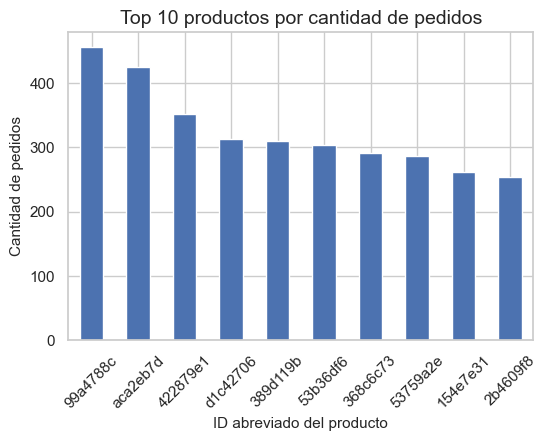

In [31]:
# Visualización
top_productos = (
    popularidad_productos
    .head(10)
    .reset_index()
)

top_productos["producto_corto"] = (
    top_productos["id_producto"].str[:8]
)

top_productos.plot(
    x="producto_corto",
    y="pedidos",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    title="Top 10 productos por cantidad de pedidos"
)

plt.xlabel("ID abreviado del producto")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=45)
plt.show()

El análisis y el ranking muestran que los productos más populares se concentran principalmente en categorías de:

- Hogar
- Belleza
- Tecnología
- Regalos

La cantidad de pedidos y clientes únicos es muy similar, lo que refuerza la idea de que la popularidad se debe principalmente a compras realizadas por distintos usuarios. Este ranking puede utilizarse como baseline para clientes sin historial, aunque los identificadores de producto por sí solos tengan poca interpretabilidad comercial.

Si ya entonces analizamos la popularidad individual de los productos, lo más natural es analizar también la popularidad por categorías, sobre todo porque los identificadores por sí solos no son explícitos en qué se está vendiendo. Esto servirá para construir un baseline más interpretable y para detectar qué categorías conviene mostrar primero a usuarios nuevos.

In [32]:
# Popularidad histórica por categoría
popularidad_categorias = (
    interacciones
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        clientes_unicos=("id_cliente_unico", "nunique"),
        productos_unicos=("id_producto", "nunique"),
        unidades_vendidas=("id_articulo_pedido", "count"),
        precio_promedio=("precio", "mean")
    )
    .sort_values("pedidos", ascending=False)
)

popularidad_categorias["porcentaje_pedidos"] = (
    popularidad_categorias["pedidos"] /
    interacciones["id_pedido"].nunique() * 100
)

popularidad_categorias.head(15)

,pedidos,clientes_unicos,productos_unicos,unidades_vendidas,precio_promedio,porcentaje_pedidos
categoria_producto,,,,,,
cama_mesa_bano,9271,9007,2990,10952,93.44,9.75
belleza_salud,8648,8499,2397,9464,130.29,9.09
deportes_ocio,7528,7339,2821,8429,113.25,7.91
informatica_accesorios,6529,6404,1599,7643,116.27,6.86
muebles_decoracion,6303,6174,2592,8156,87.24,6.63
articulos_domesticos,5743,5681,2282,6795,90.60,6.04
relojes_regalos,5493,5419,1300,5857,199.06,5.77
telefonia,4092,4046,1112,4428,69.96,4.30
automotriz,3809,3768,1853,4139,139.85,4.00


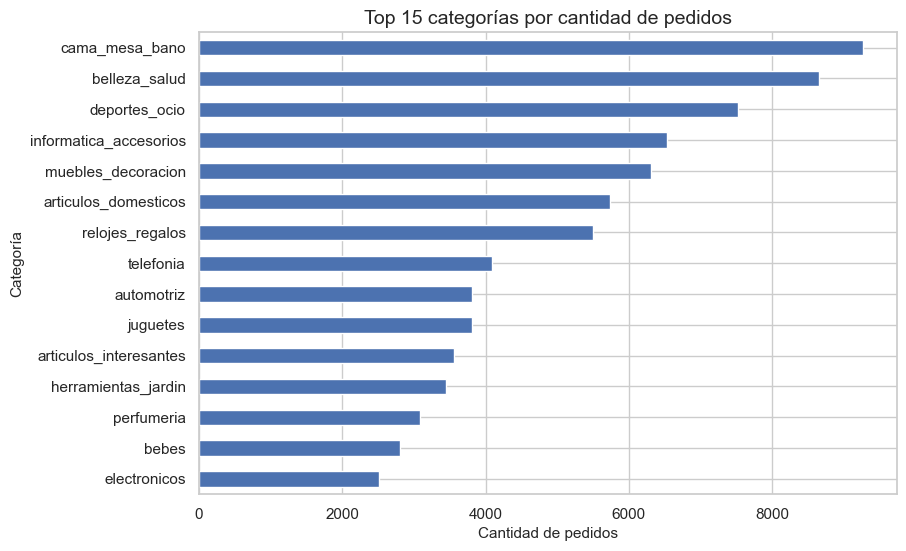

In [33]:
# Visualización
popularidad_categorias.head(15)["pedidos"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Top 15 categorías por cantidad de pedidos"
)

plt.xlabel("Cantidad de pedidos")
plt.ylabel("Categoría")
plt.show()

La demanda se concentra principalmente en categorías relacionadas con el hogar, belleza, ocio y tecnología. Las categorías más populares no siempre presentan los precios promedio más altos, por lo que un sistema de recomendación orientado al aumento del ticket debe considerar tanto la frecuencia de compra como el valor económico de cada categoría.

Esta diferencia permite distinguir entre categorías útiles para generar conversión y categorías con mayor potencial para elevar el valor de la compra.

Dicho lo anterior, resulta entonces muy útil analizar el aporte económico por categoría. Una categoría puede vender mucho pero aportar menos dinero que otra con menor volumen y productos más costosos.

In [34]:
# Crear valor total por artículo
interacciones["valor_articulo"] = (
    interacciones["precio"] +
    interacciones["valor_flete"]
)

# Resumen económico por categoría
valor_categorias = (
    interacciones
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        valor_total=("valor_articulo", "sum"),
        valor_promedio_articulo=("valor_articulo", "mean")
    )
    .sort_values("valor_total", ascending=False)
)

valor_categorias.head(15)

,pedidos,valor_total,valor_promedio_articulo
categoria_producto,,,
belleza_salud,8648,"1,412,070.00",149.20
relojes_regalos,5493,"1,264,016.98",215.81
cama_mesa_bano,9271,"1,225,052.07",111.86
deportes_ocio,7528,"1,118,004.06",132.64
informatica_accesorios,6529,"1,032,603.65",135.10
muebles_decoracion,6303,"879,835.03",107.88
articulos_domesticos,5743,"758,392.25",111.61
articulos_interesantes,3556,"691,371.51",186.10
automotriz,3809,"669,319.92",161.71


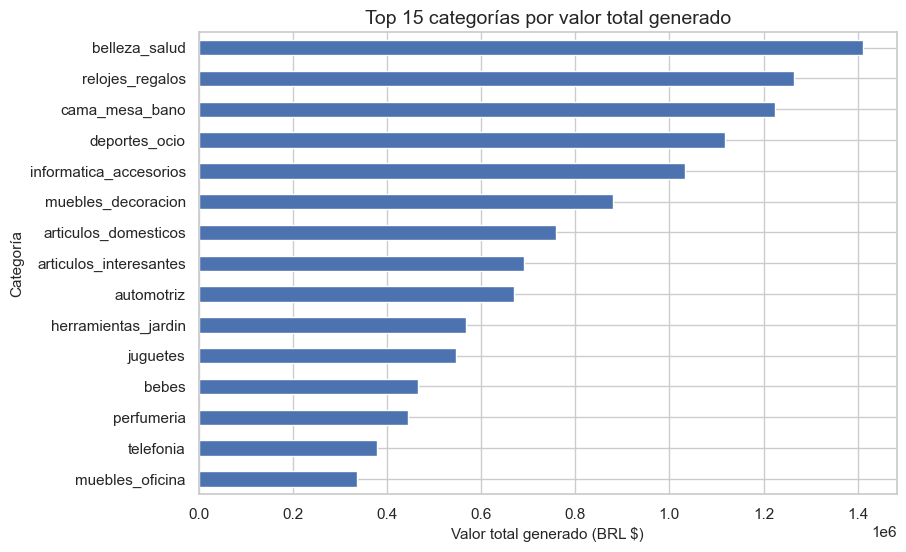

In [35]:
# Visualización
valor_categorias.head(15)["valor_total"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Top 15 categorías por valor total generado"
)

plt.xlabel("Valor total generado (BRL $)")
plt.ylabel("Categoría")
plt.show()

Como se sospechaba, los resultados muestran que popularidad y aporte económico no necesariamente coinciden perfectamente.

El valor económico no depende únicamente de la cantidad de pedidos. Aunque las categorías más populares suelen generar montos elevados, algunas categorías con menor volumen alcanzan una contribución importante debido a su mayor valor promedio por artículo. Belleza y salud lidera el valor total generado, mientras que relojes y regalos destaca por combinar una demanda relevante con uno de los valores promedio más altos.

Estos resultados sugieren que las recomendaciones deben equilibrar popularidad y potencial económico, evitando priorizar únicamente los productos más vendidos. Entonces, el siguiente paso sería segmentar las categorías por volumen y valor.

- **Cantidad de pedidos**, relacionada con demanda y probabilidad de conversión
- **Valor promedio por artículo**, relacionado con el potencial de elevar el ticket.

Esto permitirá clasificar las categorías en cuatro grupos estratégicos.

In [36]:
# Unir popularidad y valor económico por categoría
segmentacion_categorias = (
    popularidad_categorias[
        ["pedidos", "clientes_unicos", "productos_unicos"]
    ]
    .join(
        valor_categorias[
            ["valor_total", "valor_promedio_articulo"]
        ]
    )
)

# Medianas utilizadas como puntos de corte
mediana_pedidos = segmentacion_categorias["pedidos"].median()

mediana_valor = (
    segmentacion_categorias["valor_promedio_articulo"].median()
)

# Clasificar cada categoría
segmentacion_categorias["segmento"] = np.select(
    [
        (
            segmentacion_categorias["pedidos"] >= mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            >= mediana_valor
        ),
        (
            segmentacion_categorias["pedidos"] >= mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            < mediana_valor
        ),
        (
            segmentacion_categorias["pedidos"] < mediana_pedidos
        ) &
        (
            segmentacion_categorias["valor_promedio_articulo"]
            >= mediana_valor
        )
    ],
    [
        "alto_volumen_alto_valor",
        "alto_volumen_bajo_valor",
        "bajo_volumen_alto_valor"
    ],
    default="bajo_volumen_bajo_valor"
)

segmentacion_categorias.sort_values(
    ["segmento", "pedidos"],
    ascending=[True, False]
)

,pedidos,clientes_unicos,productos_unicos,valor_total,valor_promedio_articulo,segmento
categoria_producto,,,,,,
belleza_salud,8648,8499,2397,"1,412,070.00",149.20,alto_volumen_alto_valor
informatica_accesorios,6529,6404,1599,"1,032,603.65",135.10,alto_volumen_alto_valor
relojes_regalos,5493,5419,1300,"1,264,016.98",215.81,alto_volumen_alto_valor
automotriz,3809,3768,1853,"669,319.92",161.71,alto_volumen_alto_valor
juguetes,3804,3763,1373,"546,967.66",135.72,alto_volumen_alto_valor
articulos_interesantes,3556,3540,770,"691,371.51",186.10,alto_volumen_alto_valor
bebes,2808,2782,889,"464,766.65",155.91,alto_volumen_alto_valor
muebles_oficina,1254,1245,302,"335,211.36",200.97,alto_volumen_alto_valor
maletas_accesorios,1019,1013,346,"168,778.12",156.71,alto_volumen_alto_valor


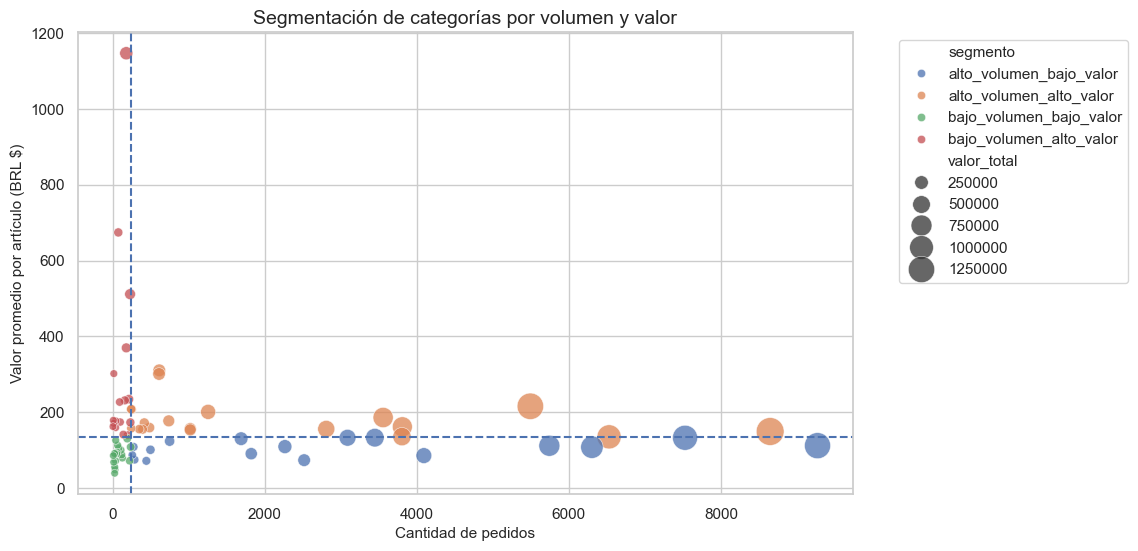

In [37]:
# Visualización
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segmentacion_categorias,
    x="pedidos",
    y="valor_promedio_articulo",
    hue="segmento",
    size="valor_total",
    sizes=(30, 400),
    alpha=0.75
)

plt.axvline(
    mediana_pedidos,
    linestyle="--"
)

plt.axhline(
    mediana_valor,
    linestyle="--"
)

plt.title("Segmentación de categorías por volumen y valor")
plt.xlabel("Cantidad de pedidos")
plt.ylabel("Valor promedio por artículo (BRL $)")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.show()

La segmentación muestra que algunas categorías combinan un volumen elevado de pedidos con un valor promedio superior, por lo que representan una prioridad para recomendaciones orientadas simultáneamente a la conversión y al ticket promedio. Esto hace que las categorías más atractivas para una estrategia que busque aumentar conversión y valor del ticket promedio al mismo tiempo sean:

- belleza_salud
- informatica_accesorios
- relojes_regalos
- automotriz
- juguetes
- articulos_interesantes
- bebes

En contraste, otras categorías presentan un alto volumen, pero un menor valor por artículo, lo que las convierte en buenas puertas de entrada para estrategias de venta cruzada que ayuden a elevar el tamaño de la canasta.

- cama_mesa_bano
- deportes_ocio
- muebles_decoracion
- articulos_domesticos

Finalmente, las categorías de bajo volumen y alto valor pueden utilizarse en recomendaciones más selectivas, aunque su menor demanda limita su utilidad como recomendaciones generales.

- computadoras
- electrodomesticos_2
- portatiles_hogar_horno_cafe

Tomando estos valiosos hayazgos en cuenta, probemos entonces medir el potencial de venta cruzada por categoría. Analizaremos qué categorías suelen aparecer en pedidos con más de un artículo, lo que resulta más útil que sólo saber cuáles venden mucho, porque identifica dónde existe mayor comportamiento histórico de compra adicional.

In [38]:
# Agregar la cantidad de artículos de cada pedido a las interacciones
interacciones_cross_sell = interacciones.merge(
    ticket_pedidos[["cantidad_articulos"]],
    left_on="id_pedido",
    right_index=True,
    how="left"
)

# Indicar si el pedido contiene más de un artículo
interacciones_cross_sell["pedido_multiproducto"] = (
    interacciones_cross_sell["cantidad_articulos"] > 1
)

# Calcular el comportamiento por categoría
cross_sell_categorias = (
    interacciones_cross_sell
    .drop_duplicates(["id_pedido", "categoria_producto"])
    .groupby("categoria_producto")
    .agg(
        pedidos=("id_pedido", "nunique"),
        pedidos_multiproducto=("pedido_multiproducto", "sum")
    )
)

cross_sell_categorias["tasa_multiproducto_pct"] = (
    cross_sell_categorias["pedidos_multiproducto"] /
    cross_sell_categorias["pedidos"] * 100
)

cross_sell_categorias.sort_values(
    "tasa_multiproducto_pct",
    ascending=False
).head(20)

,pedidos,pedidos_multiproducto,tasa_multiproducto_pct
categoria_producto,,,
hogar_confort_2,24,7,29.17
computadoras_gamer,7,2,28.57
moda_ropa_infantil_juvenil,7,2,28.57
senalizacion_seguridad,138,35,25.36
cocina,13,3,23.08
construccion_herramientas_jardin,190,43,22.63
muebles_decoracion,6303,1369,21.72
flores,29,6,20.69
construccion_herramientas_iluminacion,242,48,19.83


Para sortear que categorías con muy pocos pedidos aparezcan arriba solo por casualidad, filtramos aquellas con al menos 200 pedidos:

In [39]:
cross_sell_relevante = (
    cross_sell_categorias
    .query("pedidos >= 200")
    .sort_values(
        "tasa_multiproducto_pct",
        ascending=False
    )
)

cross_sell_relevante.head(15)

,pedidos,pedidos_multiproducto,tasa_multiproducto_pct
categoria_producto,,,
muebles_decoracion,6303,1369,21.72
construccion_herramientas_iluminacion,242,48,19.83
hogar_construccion,483,95,19.67
hogar_confort,392,75,19.13
muebles_oficina,1254,238,18.98
herramientas_jardin,3447,595,17.26
bebidas,287,45,15.68
construccion_herramientas_construccion,736,114,15.49
muebles_sala,414,64,15.46


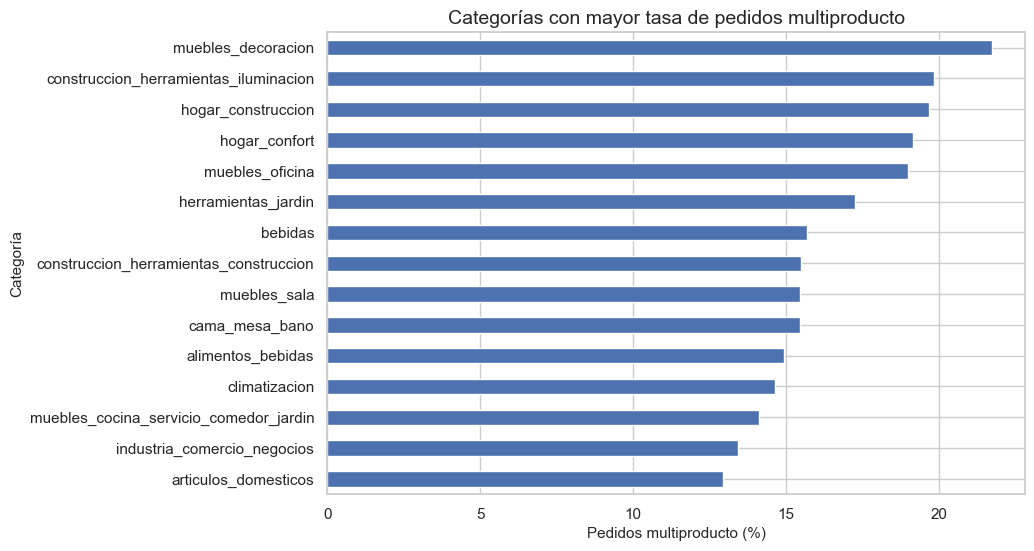

In [40]:
# Visualización
cross_sell_relevante.head(15)[
    "tasa_multiproducto_pct"
].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Categorías con mayor tasa de pedidos multiproducto"
)

plt.xlabel("Pedidos multiproducto (%)")
plt.ylabel("Categoría")
plt.show()

Estos resultados ya nos permiten identificar categorías con mejor contexto histórico de utilidad para venta cruzada. Entre las categorías con al menos 200 pedidos, destacan:

- muebles_decoracion: 21.72 % de pedidos multiproducto.
- construccion_herramientas_iluminacion: 19.83 %.
- hogar_construccion: 19.67 %.
- hogar_confort: 19.13 %.
- muebles_oficina: 18.98 %.
- herramientas_jardin: 17.26 %.

Esto sugiere que las categorías relacionadas con hogar, muebles y construcción presentan una mayor predisposición histórica a incluir artículos adicionales.

Finalmente, categorías de gran volumen como:

- cama_mesa_bano: 15.45 %
- articulos_domesticos: 12.92 %

también representan oportunidades relevantes, ya que concentran una cantidad elevada de pedidos multiproducto en términos absolutos. Estas categorías son candidatas prioritarias para recomendaciones dentro de la página del producto y del carrito.

El siguiente paso para complementar esta información es distinguir repetición de complementariedad. Un pedido con varios artículos puede contener:

- varias unidades del mismo producto;
- productos distintos de la misma categoría;
- productos de categorías diferentes.

Para el recomendador, nos interesa especialmente la tercera situación, porque refleja venta cruzada real entre categorías.

In [41]:
# Resumen de diversidad por pedido
diversidad_pedidos = (
    interacciones
    .groupby("id_pedido")
    .agg(
        articulos=("id_articulo_pedido", "count"),
        productos_unicos=("id_producto", "nunique"),
        categorias_unicas=("categoria_producto", "nunique")
    )
)

# Clasificar el tipo de canasta
diversidad_pedidos["tipo_canasta"] = np.select(
    [
        diversidad_pedidos["articulos"] == 1,

        (
            diversidad_pedidos["articulos"] > 1
        ) &
        (
            diversidad_pedidos["productos_unicos"] == 1
        ),

        (
            diversidad_pedidos["productos_unicos"] > 1
        ) &
        (
            diversidad_pedidos["categorias_unicas"] == 1
        ),

        diversidad_pedidos["categorias_unicas"] > 1
    ],
    [
        "un_solo_articulo",
        "mismo_producto",
        "productos_misma_categoria",
        "categorias_diferentes"
    ],
    default="sin_clasificar"
)

# Resumen
tipos_canasta = (
    diversidad_pedidos["tipo_canasta"]
    .value_counts()
    .to_frame("pedidos")
)

tipos_canasta["porcentaje"] = (
    tipos_canasta["pedidos"] /
    len(diversidad_pedidos) * 100
)

tipos_canasta.round(2)

,pedidos,porcentaje
tipo_canasta,,
un_solo_articulo,85637,90.02
mismo_producto,6349,6.67
productos_misma_categoria,2418,2.54
categorias_diferentes,724,0.76


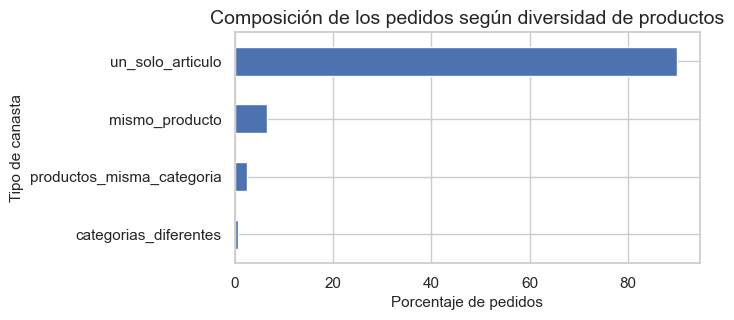

In [42]:
# Visualización
tipos_canasta["porcentaje"].sort_values().plot(
    kind="barh",
    figsize=(6, 3),
    title="Composición de los pedidos según diversidad de productos"
)

plt.xlabel("Porcentaje de pedidos")
plt.ylabel("Tipo de canasta")
plt.show()

La composición de las canastas confirma que la mayoría de los pedidos tiene una profundidad muy baja. El 90.02 % contiene un solo artículo, mientras que el 6.67 % incluye varias unidades del mismo producto. Solo el 2.54 % reúne productos distintos dentro de una misma categoría y apenas el 0.76 % combina categorías diferentes.

Este resultado muestra que la venta cruzada entre categorías es todavía muy limitada, pero precisamente por eso representa una oportunidad relevante para el negocio. El sistema de recomendación debería enfocarse en sugerir productos complementarios, primero dentro de la misma categoría y, cuando existan asociaciones suficientemente confiables, entre categorías relacionadas.

Además, la baja presencia de canastas diversas explica por qué las reglas de asociación presentan frecuencias reducidas y por qué será necesario combinar estas reglas con estrategias de popularidad y similitud de productos.

Aumentar la proporción de pedidos con productos distintos podría contribuir directamente a elevar la cantidad de artículos por compra y, como consecuencia, el ticket promedio. 

La conversión, en cambio, deberá evaluarse posteriormente con datos de visitas, clics o mediante pruebas A/B, ya que este dataset solo registra compras realizadas.

In [43]:
# Dimensiones de la matriz cliente-producto
clientes_unicos = interacciones["id_cliente_unico"].nunique()
productos_unicos = interacciones["id_producto"].nunique()

interacciones_observadas = (
    interacciones[
        ["id_cliente_unico", "id_producto"]
    ]
    .drop_duplicates()
    .shape[0]
)

interacciones_posibles = (
    clientes_unicos * productos_unicos
)

densidad_matriz = (
    interacciones_observadas /
    interacciones_posibles * 100
)

dispersion_matriz = 100 - densidad_matriz

print(f"Clientes únicos: {clientes_unicos:,}")
print(f"Productos únicos: {productos_unicos:,}")
print(f"Interacciones observadas: {interacciones_observadas:,}")
print(f"Interacciones posibles: {interacciones_posibles:,}")
print(f"Densidad de la matriz: {densidad_matriz:.6f}%")
print(f"Dispersión de la matriz: {dispersion_matriz:.6f}%")

Clientes únicos: 92,081
Productos únicos: 31,625
Interacciones observadas: 98,370
Interacciones posibles: 2,912,061,625
Densidad de la matriz: 0.003378%
Dispersión de la matriz: 99.996622%


La matriz cliente-producto presenta una densidad extremadamente baja, debido al elevado número de clientes y productos frente a la reducida cantidad de interacciones observadas. Esta dispersión confirma que la mayoría de los clientes tiene poco historial y que muchos productos cuentan con pocas compras. Por ello, un modelo basado exclusivamente en filtrado colaborativo podría tener dificultades para generar recomendaciones confiables para una gran parte de los usuarios.

## Resumen de hallazgos principales del EDA

El análisis exploratorio muestra que el comportamiento de compra dentro del marketplace presenta una baja recurrencia y una escasa profundidad de canasta. El 97.02 % de los clientes realizó un solo pedido y el 90.02 % de las compras contiene un único artículo. Además, únicamente el 0.76 % de los pedidos combina productos de categorías diferentes, lo que evidencia que la venta cruzada todavía tiene una presencia muy limitada.

A pesar de esta baja diversidad, se encontró una relación positiva entre la cantidad de artículos y el ticket promedio. Los pedidos con un solo artículo alcanzan un ticket promedio de BRL $150.10, mientras que aquellos con cinco o más artículos llegan a BRL $581.87. Este comportamiento respalda la oportunidad de utilizar recomendaciones complementarias para incrementar la profundidad de las canastas y contribuir al aumento del ticket promedio.

La demanda se concentra principalmente en categorías como cama, mesa y baño, belleza y salud, deportes y ocio, informática y accesorios, y muebles y decoración. Sin embargo, las categorías más populares no siempre son las que generan el mayor valor económico. Belleza y salud lidera el valor total generado, mientras que relojes y regalos destaca por su elevado valor promedio por artículo. Esto indica que una estrategia de recomendación no debería basarse únicamente en popularidad, sino también en el potencial económico de los productos recomendados.

Las asociaciones entre productos presentan frecuencias reducidas debido al elevado número de productos únicos y a la baja cantidad de pedidos multiproducto. Las asociaciones entre categorías resultan más interpretables, aunque la mayoría muestra una fuerza limitada. Por esta razón, las reglas de compra conjunta pueden utilizarse como apoyo para la venta cruzada, pero no deberían ser el único mecanismo del sistema.

Finalmente, la matriz cliente-producto presenta una densidad de apenas 0.003378 % y una dispersión de 99.996622 %. Esta estructura confirma un problema severo de cold start y limita la viabilidad de utilizar exclusivamente filtrado colaborativo. En consecuencia, el sistema deberá combinar popularidad, categorías, similitud entre productos y asociaciones de compra, reservando la personalización basada en historial para la pequeña proporción de clientes recurrentes.

## Justificación del enfoque de recomendación

Los resultados del análisis exploratorio indican que el sistema de recomendación no debería basarse exclusivamente en filtrado colaborativo. La mayoría de los clientes cuenta con un historial mínimo, ya que el 97.02 % realizó un solo pedido, mientras que la matriz cliente-producto presenta una dispersión superior al 99.99 %. Esto reduce considerablemente la cantidad de información disponible para identificar preferencias individuales confiables.

Por esta razón, se propone un enfoque híbrido que combine varias estrategias. Para los usuarios sin historial suficiente, se utilizará un baseline de popularidad general o por categoría. Para los clientes que consulten o hayan comprado un producto específico, se podrán generar recomendaciones mediante similitud de categoría y asociaciones de compra. Finalmente, para el pequeño grupo de clientes recurrentes, será posible incorporar recomendaciones personalizadas a partir de su historial.

Las recomendaciones también deberán considerar el valor económico de los productos. El análisis mostró que las categorías más populares no siempre son las que presentan mayor valor promedio, por lo que el sistema debería equilibrar relevancia y potencial de incremento del ticket. De esta manera, se evitaría recomendar únicamente productos muy vendidos y se daría prioridad a alternativas complementarias que mantengan coherencia con el interés del usuario.

En consecuencia, la estrategia propuesta estará compuesta por:

- recomendaciones de popularidad para usuarios nuevos;
- productos populares dentro de una categoría;
- productos similares por características disponibles;
- asociaciones de compra para venta cruzada;
- personalización basada en historial para clientes recurrentes.

Este enfoque responde mejor a las características reales del dataset y permite cubrir distintos escenarios de usuario. Además, podrá evaluarse mediante métricas como Precision@K y Recall@K, comparando los resultados contra un baseline de popularidad. El impacto sobre la conversión deberá validarse posteriormente mediante datos de navegación o pruebas A/B, mientras que el efecto sobre el ticket promedio podrá analizarse a partir del valor de las canastas y la cantidad de artículos por pedido.

# ETL

A partir de los resultados del análisis exploratorio se construyen tablas con distintas granularidades para facilitar su uso posterior en consultas SQL, modelos de Machine Learning y dashboards de Power BI.

La transformación separa las entidades principales del dataset y evita la duplicación generada por la relación entre artículos y múltiples medios o secuencias de pago.

### 1. Tabla de hechos, interacciones

La tabla `fact_interacciones` conserva una fila por artículo incluido en cada pedido. Esta granularidad elimina las repeticiones generadas por las distintas secuencias de pago y permite analizar correctamente las relaciones entre clientes, productos y categorías.

También se incorporó una variable de interacción implícita con valor 1, que podrá utilizarse para construir la matriz cliente-producto y entrenar modelos de recomendación. El valor del artículo incluye el precio y el flete asociados a cada registro.

In [48]:
# Crear tabla de interacciones cliente-producto
fact_interacciones = interacciones[
    [
        "id_pedido",
        "id_articulo_pedido",
        "id_cliente_unico",
        "id_producto",
        "categoria_producto",
        "id_vendedor",
        "precio",
        "valor_flete",
        "fecha_compra"
    ]
].copy()

# Convertir la fecha de compra
fact_interacciones["fecha_compra"] = pd.to_datetime(
    fact_interacciones["fecha_compra"],
    errors="coerce"
)

# Crear valor económico por artículo
fact_interacciones["valor_articulo"] = (
    fact_interacciones["precio"] +
    fact_interacciones["valor_flete"]
)

# Crear una variable de interacción implícita para ML
fact_interacciones["interaccion"] = 1

# Crear una llave para relacionarla con la dimensión de fechas
fact_interacciones["id_fecha_compra"] = (
    fact_interacciones["fecha_compra"]
    .dt.strftime("%Y%m%d")
    .astype("int64")
)

# Ordenar los registros
fact_interacciones = (
    fact_interacciones
    .sort_values(
        ["fecha_compra", "id_pedido", "id_articulo_pedido"]
    )
    .reset_index(drop=True)
)

fact_interacciones.head()

,id_pedido,id_articulo_pedido,id_cliente_unico,id_producto,categoria_producto,id_vendedor,precio,valor_flete,fecha_compra,valor_articulo,interaccion,id_fecha_compra
0,3b697a20d9e427646d92567910af6d57,1,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,relojes_regalos,522620dcb18a6b31cd7bdf73665113a9,29.90,15.56,2016-10-03 09:44:50,45.46,1,20161003
1,be5bc2f0da14d8071e2d45451ad119d9,1,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,deportes_ocio,f09b760d23495ac9a7e00d29b769007c,21.90,17.19,2016-10-03 16:56:50,39.09,1,20161003
2,65d1e226dfaeb8cdc42f665422522d14,1,b8b8726af116a5cfb35b0315ecef9172,9c7bdf67b06b419aefb93cfdfc96c55d,deportes_ocio,ed49da7cadefc454d6a67de249eab240,21.50,14.11,2016-10-03 21:01:41,35.61,1,20161003
3,a41c8759fbe7aab36ea07e038b2d4465,1,61db744d2f835035a5625b59350c6b63,b72b39418216e944bb34e35f4d3ea8c7,deportes_ocio,45d33f715e24d15a6ccf5c17b3a23e3c,36.49,17.24,2016-10-03 21:13:36,53.73,1,20161003
4,d207cc272675637bfed0062edffd0818,1,8d3a54507421dbd2ce0a1d58046826e0,107177bf61755f05c604fe57e02467d6,muebles_decoracion,cca3071e3e9bb7d12640c9fbe2301306,119.90,13.56,2016-10-03 22:06:03,133.46,1,20161003


In [46]:
# Validación
print(f"Filas: {len(fact_interacciones):,}")
print(
    "Duplicados pedido-artículo:",
    fact_interacciones.duplicated(
        subset=["id_pedido", "id_articulo_pedido"]
    ).sum()
)

print(
    "Valores nulos:",
    fact_interacciones.isna().sum().sum()
)

Filas: 108,640
Duplicados pedido-artículo: 0
Valores nulos: 0


### 2. Tabla de hechos, pedidos

La tabla `fact_pedidos` consolida cada compra en un solo registro. Incluye el cliente asociado, las fechas principales, la cantidad de artículos, la diversidad de productos y categorías, así como el valor económico total del pedido.

Esta granularidad evita duplicar importes y facilita el cálculo de métricas como ticket promedio, pedidos multiproducto y evolución temporal de las ventas.

In [ ]:
# Crear tabla con una fila por pedido
fact_pedidos = (
    interacciones
    .groupby("id_pedido", as_index=False)
    .agg(
        id_cliente_unico=("id_cliente_unico", "first"),
        estado_pedido=("estado_pedido", "first"),
        ciudad_cliente=("ciudad_cliente", "first"),
        estado_cliente=("estado_cliente", "first"),
        fecha_compra=("fecha_compra", "first"),
        fecha_aprobacion_pedido=("fecha_aprobacion_pedido", "first"),
        fecha_entrega_cliente=("fecha_entrega_cliente", "first"),
        fecha_estimada_entrega=("fecha_estimada_entrega", "first"),
        cantidad_articulos=("id_articulo_pedido", "count"),
        productos_unicos=("id_producto", "nunique"),
        categorias_unicas=("categoria_producto", "nunique"),
        valor_productos=("precio", "sum"),
        valor_flete=("valor_flete", "sum")
    )
)
# =================================
# Creación de variables derivadas
# =================================

# Crear ticket total
fact_pedidos["ticket_total"] = (
    fact_pedidos["valor_productos"] +
    fact_pedidos["valor_flete"]
)

# Crear tipo de canasta
fact_pedidos["tipo_canasta"] = np.select(
    [
        fact_pedidos["cantidad_articulos"] == 1,

        (
            fact_pedidos["cantidad_articulos"] > 1
        ) &
        (
            fact_pedidos["productos_unicos"] == 1
        ),

        (
            fact_pedidos["productos_unicos"] > 1
        ) &
        (
            fact_pedidos["categorias_unicas"] == 1
        ),

        fact_pedidos["categorias_unicas"] > 1
    ],
    [
        "un_solo_articulo",
        "mismo_producto",
        "productos_misma_categoria",
        "categorias_diferentes"
    ],
    default="sin_clasificar"
)

# =================================
# Creación de variables temporales
# =================================

# Convertir fechas
columnas_fecha_pedidos = [
    "fecha_compra",
    "fecha_aprobacion_pedido",
    "fecha_entrega_cliente",
    "fecha_estimada_entrega"
]

fact_pedidos[columnas_fecha_pedidos] = (
    fact_pedidos[columnas_fecha_pedidos]
    .apply(pd.to_datetime, errors="coerce")
)

# Crear llave de fecha
fact_pedidos["id_fecha_compra"] = (
    fact_pedidos["fecha_compra"]
    .dt.strftime("%Y%m%d")
    .astype("int64")
)

# Crear variables temporales
fact_pedidos["anio_compra"] = (
    fact_pedidos["fecha_compra"].dt.year
)

fact_pedidos["mes_compra"] = (
    fact_pedidos["fecha_compra"].dt.month
)

fact_pedidos["anio_mes_compra"] = (
    fact_pedidos["fecha_compra"]
    .dt.to_period("M")
    .astype(str)
)

# =================================
# Creación de indicadores útiles para PowerBI
# =================================

# Indicadores de comportamiento de compra
fact_pedidos["pedido_multiproducto"] = (
    fact_pedidos["cantidad_articulos"] > 1
).astype(int)

fact_pedidos["pedido_multicategoria"] = (
    fact_pedidos["categorias_unicas"] > 1
).astype(int)

# Indicador de entrega tardía
fact_pedidos["entrega_tardia"] = (
    fact_pedidos["fecha_entrega_cliente"] >
    fact_pedidos["fecha_estimada_entrega"]
).astype(int)

# =================================
# Ordenamiento de la tabla
# =================================

fact_pedidos = (
    fact_pedidos
    .sort_values(["fecha_compra", "id_pedido"])
    .reset_index(drop=True)
)

fact_pedidos.head()

,id_pedido,id_cliente_unico,estado_pedido,ciudad_cliente,estado_cliente,fecha_compra,fecha_aprobacion_pedido,fecha_entrega_cliente,fecha_estimada_entrega,cantidad_articulos,productos_unicos,categorias_unicas,valor_productos,valor_flete,ticket_total,tipo_canasta,id_fecha_compra,anio_compra,mes_compra,anio_mes_compra,pedido_multiproducto,pedido_multicategoria,entrega_tardia
0,3b697a20d9e427646d92567910af6d57,32ea3bdedab835c3aa6cb68ce66565ef,entregado,sao paulo,SP,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-26 14:02:13,2016-10-27,1,1,1,29.90,15.56,45.46,un_solo_articulo,20161003,2016,10,2016-10,0,0,0
1,be5bc2f0da14d8071e2d45451ad119d9,2f64e403852e6893ae37485d5fcacdaf,entregado,panambi,RS,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-27 18:19:38,2016-11-07,1,1,1,21.90,17.19,39.09,un_solo_articulo,20161003,2016,10,2016-10,0,0,0
2,65d1e226dfaeb8cdc42f665422522d14,b8b8726af116a5cfb35b0315ecef9172,cancelado,rio de janeiro,RJ,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-11-08 10:58:34,2016-11-25,1,1,1,21.50,14.11,35.61,un_solo_articulo,20161003,2016,10,2016-10,0,0,0
3,a41c8759fbe7aab36ea07e038b2d4465,61db744d2f835035a5625b59350c6b63,entregado,porto alegre,RS,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-11-03 10:58:07,2016-11-29,1,1,1,36.49,17.24,53.73,un_solo_articulo,20161003,2016,10,2016-10,0,0,0
4,d207cc272675637bfed0062edffd0818,8d3a54507421dbd2ce0a1d58046826e0,entregado,hortolandia,SP,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-31 11:07:42,2016-11-23,1,1,1,119.90,13.56,133.46,un_solo_articulo,20161003,2016,10,2016-10,0,0,0


In [52]:
# Validación
print(f"Filas: {len(fact_pedidos):,}")
print(
    "Pedidos únicos:",
    fact_pedidos["id_pedido"].nunique()
)

print(
    "Duplicados por pedido:",
    fact_pedidos["id_pedido"].duplicated().sum()
)

print(
    "Ticket promedio:",
    f"BRL $ {fact_pedidos['ticket_total'].mean():,.2f}"
)

Filas: 95,128
Pedidos únicos: 95128
Duplicados por pedido: 0
Ticket promedio: BRL $ 159.97


### 3. Tabla de hechos, pagos

La tabla `fact_pagos` conserva una fila por secuencia de pago asociada a cada pedido. Su separación evita que los importes se multipliquen por la cantidad de artículos del pedido y permite analizar correctamente métodos de pago, cuotas y valores pagados.

In [57]:
# Seleccionar las variables propias de cada pago
fact_pagos = (
    df_es[
        [
            "id_pedido",
            "secuencia_pago",
            "tipo_pago",
            "cuotas_pago",
            "valor_pago"
        ]
    ]
    .drop_duplicates()
    .copy()
)

# Ordenar los registros
fact_pagos = (
    fact_pagos
    .sort_values(
        ["id_pedido", "secuencia_pago"]
    )
    .reset_index(drop=True)
)

# Creación de primary key para cada pago
fact_pagos["id_pago"] = (
    fact_pagos["id_pedido"].astype(str)
    + "_"
    + fact_pagos["secuencia_pago"].astype(str)
)

# Reordenamiento de columnas
fact_pagos = fact_pagos[
    [
        "id_pago",
        "id_pedido",
        "secuencia_pago",
        "tipo_pago",
        "cuotas_pago",
        "valor_pago"
    ]
]

fact_pagos

,id_pago,id_pedido,secuencia_pago,tipo_pago,cuotas_pago,valor_pago
0,00010242fe8c5a6d1ba2dd792cb16214_1,00010242fe8c5a6d1ba2dd792cb16214,1,tarjeta_credito,2,72.19
1,00018f77f2f0320c557190d7a144bdd3_1,00018f77f2f0320c557190d7a144bdd3,1,tarjeta_credito,3,259.83
2,000229ec398224ef6ca0657da4fc703e_1,000229ec398224ef6ca0657da4fc703e,1,tarjeta_credito,5,216.87
3,00024acbcdf0a6daa1e931b038114c75_1,00024acbcdf0a6daa1e931b038114c75,1,tarjeta_credito,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9_1,00042b26cf59d7ce69dfabb4e55b4fd9,1,tarjeta_credito,3,218.04
...,...,...,...,...,...,...
99324,fffc94f6ce00a00581880bf54a75a037_1,fffc94f6ce00a00581880bf54a75a037,1,boleto_bancario,1,343.40
99325,fffcd46ef2263f404302a634eb57f7eb_1,fffcd46ef2263f404302a634eb57f7eb,1,boleto_bancario,1,386.53
99326,fffce4705a9662cd70adb13d4a31832d_1,fffce4705a9662cd70adb13d4a31832d,1,tarjeta_credito,3,116.85
99327,fffe18544ffabc95dfada21779c9644f_1,fffe18544ffabc95dfada21779c9644f,1,tarjeta_credito,3,64.71


In [55]:
# Validación
print(f"Filas de pago: {len(fact_pagos):,}")

print(
    "Pagos únicos:",
    fact_pagos["id_pago"].nunique()
)

print(
    "Duplicados por pedido y secuencia:",
    fact_pagos.duplicated(
        subset=["id_pedido", "secuencia_pago"]
    ).sum()
)

print(
    "Pedidos con pago:",
    fact_pagos["id_pedido"].nunique()
)

print(
    "Valores nulos:",
    fact_pagos.isna().sum().sum()
)

Filas de pago: 99,329
Pagos únicos: 99329
Duplicados por pedido y secuencia: 0
Pedidos con pago: 95128
Valores nulos: 0


**Comprobar la relación con los pedidos**

La suma de pagos por pedido debería aproximarse al ticket calculado con productos y flete. No es necesario exigir diferencia exactamente igual a cero en todos los casos, porque pueden existir redondeos o particularidades del origen. Lo importante es que los valores sean razonablemente consistentes y que no aparezcan importes multiplicados por el número de artículos.

In [56]:
# Sumar los pagos registrados por pedido
pagos_por_pedido = (
    fact_pagos
    .groupby("id_pedido", as_index=False)
    .agg(
        valor_pagado=("valor_pago", "sum"),
        cantidad_pagos=("id_pago", "count")
    )
)

# Comparar pagos contra ticket
validacion_pagos = fact_pedidos[
    ["id_pedido", "ticket_total"]
].merge(
    pagos_por_pedido,
    on="id_pedido",
    how="left"
)

validacion_pagos["diferencia"] = (
    validacion_pagos["valor_pagado"] -
    validacion_pagos["ticket_total"]
)

validacion_pagos[
    [
        "ticket_total",
        "valor_pagado",
        "diferencia"
    ]
].describe()

,ticket_total,valor_pagado,diferencia
count,"95,128.00","95,128.00","95,128.00"
mean,159.97,160.06,0.09
std,218.68,218.77,4.23
min,9.59,9.59,-51.62
25%,61.97,62.01,0.00
50%,105.15,105.24,0.00
75%,176.81,176.88,0.00
max,"13,664.08","13,664.08",966.40


### 4. Tabla de dimensión, clientes

La tabla `dim_clientes` contiene una fila por cliente único y resume su información geográfica y su historial básico de compra.

Incluye la ciudad, el estado y el prefijo postal del cliente, además de la cantidad de pedidos realizados, los productos comprados, la diversidad de productos y las fechas de su primera y última compra.

Esta tabla facilitará consultas de recurrencia, segmentación de clientes, análisis geográficos y la creación de visualizaciones en Power BI, además de servir como apoyo para modelos que requieran características agregadas por cliente.

In [58]:
# Crear dimensión de clientes
dim_clientes = (
    interacciones
    .groupby("id_cliente_unico", as_index=False)
    .agg(
        ciudad_cliente=("ciudad_cliente", "first"),
        estado_cliente=("estado_cliente", "first"),
        prefijo_codigo_postal_cliente=(
            "prefijo_codigo_postal_cliente",
            "first"
        ),
        cantidad_pedidos=("id_pedido", "nunique"),
        productos_comprados=("id_producto", "count"),
        productos_unicos=("id_producto", "nunique"),
        primera_compra=("fecha_compra", "min"),
        ultima_compra=("fecha_compra", "max")
    )
)

dim_clientes.head()

,id_cliente_unico,ciudad_cliente,estado_cliente,prefijo_codigo_postal_cliente,cantidad_pedidos,productos_comprados,productos_unicos,primera_compra,ultima_compra
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,7787,1,1,1,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,6053,1,1,1,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,sao jose,SC,88115,1,1,1,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,66812,1,1,1,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,18040,1,1,1,2017-11-14 19:45:42,2017-11-14 19:45:42


In [59]:
# Validación
print(f"Clientes: {len(dim_clientes):,}")
print(
    "Duplicados:",
    dim_clientes["id_cliente_unico"].duplicated().sum()
)

Clientes: 92,081
Duplicados: 0


### 5. Tabla de dimensión, productos

La tabla `dim_productos` contiene una fila por producto único y reúne sus principales características descriptivas, físicas y comerciales.

Incluye la categoría, dimensiones, peso, cantidad de fotografías y métricas agregadas como número de pedidos, clientes únicos, unidades vendidas y precio promedio.

Esta tabla facilitará consultas de catálogo, análisis por categoría, construcción de dashboards y generación de características para modelos de recomendación basados en similitud de productos.

In [60]:
# Crear dimensión de productos
dim_productos = (
    interacciones
    .groupby("id_producto", as_index=False)
    .agg(
        categoria_producto=("categoria_producto", "first"),
        longitud_nombre_producto=("longitud_nombre_producto", "first"),
        longitud_descripcion_producto=("longitud_descripcion_producto", "first"),
        cantidad_fotos_producto=("cantidad_fotos_producto", "first"),
        peso_producto_g=("peso_producto_g", "first"),
        largo_producto_cm=("largo_producto_cm", "first"),
        alto_producto_cm=("alto_producto_cm", "first"),
        ancho_producto_cm=("ancho_producto_cm", "first"),
        cantidad_pedidos=("id_pedido", "nunique"),
        clientes_unicos=("id_cliente_unico", "nunique"),
        unidades_vendidas=("id_articulo_pedido", "count"),
        precio_promedio=("precio", "mean")
    )
)

# Redondear el precio promedio
dim_productos["precio_promedio"] = (
    dim_productos["precio_promedio"].round(2)
)

dim_productos.head()

,id_producto,categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_producto_g,largo_producto_cm,alto_producto_cm,ancho_producto_cm,cantidad_pedidos,clientes_unicos,unidades_vendidas,precio_promedio
0,00066f42aeeb9f3007548bb9d3f33c38,perfumeria,53.00,596.00,6.00,300.00,20.00,16.00,16.00,1,1,1,101.65
1,00088930e925c41fd95ebfe695fd2655,automotriz,56.00,752.00,4.00,"1,225.00",55.00,10.00,26.00,1,1,1,129.90
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_bano,50.00,266.00,2.00,300.00,45.00,15.00,35.00,1,1,1,229.00
3,000b8f95fcb9e0096488278317764d19,articulos_domesticos,25.00,364.00,3.00,550.00,19.00,24.00,12.00,2,2,2,58.90
4,000d9be29b5207b54e86aa1b1ac54872,relojes_regalos,48.00,613.00,4.00,250.00,22.00,11.00,15.00,1,1,1,199.00


In [62]:
# Validación
print(f"Productos: {len(dim_productos):,}")

print(
    "Productos únicos:",
    dim_productos["id_producto"].nunique()
)

print(
    "Duplicados:",
    dim_productos["id_producto"].duplicated().sum()
)

Productos: 31,625
Productos únicos: 31625
Duplicados: 0


### 6. Tabla de dimensión, fechas

La tabla `dim_fechas` contiene una fila por cada fecha incluida en el periodo analizado.

Incluye atributos como año, mes, trimestre, día de la semana y nombre del mes, lo que facilitará consultas temporales en SQL y la creación de jerarquías de fecha en Power BI.

Esta dimensión se relacionará con las tablas de hechos mediante la variable `id_fecha_compra`.

In [66]:
# Crear rango completo de fechas
rango_fechas = pd.date_range(
    start=fact_pedidos["fecha_compra"].min().normalize(),
    end=fact_pedidos["fecha_compra"].max().normalize(),
    freq="D"
)

# Crear dimensión de fechas
dim_fechas = pd.DataFrame({
    "fecha": rango_fechas
})

# Crear llave de fecha
dim_fechas["id_fecha"] = (
    dim_fechas["fecha"]
    .dt.strftime("%Y%m%d")
    .astype("int64")
)

# Crear atributos temporales
dim_fechas["anio"] = dim_fechas["fecha"].dt.year
dim_fechas["trimestre"] = dim_fechas["fecha"].dt.quarter
dim_fechas["mes"] = dim_fechas["fecha"].dt.month
dim_fechas["nombre_mes"] = (
    dim_fechas["fecha"]
    .dt.month_name()
    .replace(meses_es)
)

dim_fechas["dia"] = dim_fechas["fecha"].dt.day
dim_fechas["dia_semana"] = (
    dim_fechas["fecha"].dt.dayofweek + 1
)

dim_fechas["nombre_dia"] = (
    dim_fechas["fecha"]
    .dt.day_name()
    .replace(dias_es)
)

dim_fechas["anio_mes"] = (
    dim_fechas["fecha"]
    .dt.to_period("M")
    .astype(str)
)

# Reordenar columnas
dim_fechas = dim_fechas[
    [
        "id_fecha",
        "fecha",
        "anio",
        "trimestre",
        "mes",
        "nombre_mes",
        "dia",
        "dia_semana",
        "nombre_dia",
        "anio_mes"
    ]
]

dim_fechas.head()

,id_fecha,fecha,anio,trimestre,mes,nombre_mes,dia,dia_semana,nombre_dia,anio_mes
0,20161003,2016-10-03,2016,4,10,octubre,3,1,lunes,2016-10
1,20161004,2016-10-04,2016,4,10,octubre,4,2,martes,2016-10
2,20161005,2016-10-05,2016,4,10,octubre,5,3,miercoles,2016-10
3,20161006,2016-10-06,2016,4,10,octubre,6,4,jueves,2016-10
4,20161007,2016-10-07,2016,4,10,octubre,7,5,viernes,2016-10


In [67]:
# Validación
print(f"Fechas: {len(dim_fechas):,}")

print(
    "Fechas únicas:",
    dim_fechas["id_fecha"].nunique()
)

print(
    "Duplicados:",
    dim_fechas["id_fecha"].duplicated().sum()
)

Fechas: 696
Fechas únicas: 696
Duplicados: 0


## Exportación de las tablas transformadas

Las tablas generadas durante el ETL se exportan en formatos CSV y Parquet dentro de la carpeta `data/processed`.

Los archivos CSV facilitan su carga en bases de datos SQL y Power BI, mientras que el formato Parquet conserva mejor los tipos de datos, ocupa menos espacio y resulta conveniente para procesos de Machine Learning.

De esta manera, cada integrante del equipo podrá trabajar con tablas limpias y con una granularidad definida, sin depender directamente del archivo original.

In [ ]:
%pip install pyarrow fastparquet

In [72]:
from pathlib import Path

# Crear carpeta para los datos procesados
ruta_salida = Path("data/processed")
ruta_salida.mkdir(parents=True, exist_ok=True)

# Tablas finales del ETL
tablas_etl = {
    "fact_interacciones": fact_interacciones,
    "fact_pedidos": fact_pedidos,
    "fact_pagos": fact_pagos,
    "dim_clientes": dim_clientes,
    "dim_productos": dim_productos,
    "dim_fechas": dim_fechas
}

# Exportar tablas en CSV y Parquet
for nombre, tabla in tablas_etl.items():

    tabla.to_csv(
        ruta_salida / f"{nombre}.csv",
        index=False
    )

    tabla.to_parquet(
        ruta_salida / f"{nombre}.parquet",
        index=False,
        engine="fastparquet"
    )

    print(f"{nombre}: {len(tabla):,} filas exportadas")

fact_interacciones: 108,640 filas exportadas
fact_pedidos: 95,128 filas exportadas
fact_pagos: 99,329 filas exportadas
dim_clientes: 92,081 filas exportadas
dim_productos: 31,625 filas exportadas
dim_fechas: 696 filas exportadas
